# 🏁 Predicción de Estrategia de Pit Stops y Rendimiento en Fórmula 1


## 1. Introducción

La Fórmula 1 es mucho más que autos rápidos dando vueltas a un circuito. Durante una carrera, los equipos deben tomar decisiones estratégicas constantemente para intentar ganar tiempo frente a sus rivales. Entre esas decisiones, una de las más importantes es determinar el momento adecuado para realizar una parada en boxes (pit stop).

Factores como el desgaste de los neumáticos, el ritmo del piloto, la posición en pista y el avance de la carrera pueden influir directamente en esta decisión. Por esta razón, la Fórmula 1 representa un escenario ideal para aplicar técnicas de análisis de datos y Machine Learning.

En este proyecto se utilizarán datos históricos de carreras para estudiar dos problemas diferentes:

- Clasificación: predecir si un piloto realizará una parada en boxes en la siguiente vuelta.
- Regresión: estimar el tiempo que realizará un piloto en una vuelta determinada.

Para ello se entrenarán y compararán dos algoritmos ampliamente utilizados en Machine Learning:

- Support Vector Machines (SVM)
- Random Forest (RF)

A lo largo del proyecto se realizará un proceso completo de análisis, preparación de datos, entrenamiento, evaluación y optimización de modelos, con el objetivo de entender qué variables influyen en el rendimiento de carrera y qué tan bien pueden anticiparse ciertos eventos estratégicos.

________________________________________________________________________________
## 2. Objetivos

### Objetivo General
Desarrollar modelos de Machine Learning capaces de predecir decisiones estratégicas y el rendimiento de pilotos de Fórmula 1 utilizando información disponible a nivel de vuelta.

### Objetivos Específicos
- Comprender la estructura y el comportamiento del dataset mediante análisis exploratorio.
- Identificar problemas de calidad de datos y aplicar procesos de limpieza cuando sea necesario.
- Preparar los datos para su utilización en modelos de Machine Learning.
- Construir modelos de clasificación para predecir la variable PitNextLap.
- Construir modelos de regresión para predecir el tiempo de vuelta LapTime (s).
- Evaluar el desempeño de los modelos utilizando métricas apropiadas para cada problema.
- Comparar el comportamiento de los algoritmos SVM y Random Forest.
- Analizar los resultados obtenidos e identificar posibles oportunidades de mejora.

________________________________________________________________________________
## 3. Descripción del Dataset

El conjunto de datos utilizado en este proyecto corresponde al dataset "F1 Strategy Dataset | Pit Stop Prediction", disponible en Kaggle.

Cada fila del dataset representa la información de una vuelta realizada por un piloto durante una carrera de Fórmula 1. Gracias a este nivel de detalle es posible analizar cómo evoluciona el rendimiento de los pilotos a lo largo de una carrera y cómo ciertas variables pueden influir en las decisiones estratégicas.

El dataset incluye información relacionada con:

- Temporada y carrera disputada.
- Piloto participante.
- Tiempo de vuelta.
- Posición en carrera.
- Estado y desgaste de los neumáticos.
- Progreso de la carrera.
- Eventos asociados a paradas en boxes.

Además, incorpora algunas variables derivadas que ayudan a describir fenómenos importantes de la competición, como la degradación acumulada de los neumáticos o las variaciones del tiempo de vuelta entre vueltas consecutivas.

Para este proyecto se trabajará con dos variables objetivo:

- PitNextLap: indica si el piloto realizará una parada en boxes en la siguiente vuelta. Se utilizará para el problema de clasificación.
- LapTime (s): representa el tiempo de vuelta del piloto en segundos. Se utilizará para el problema de regresión.

________________________________________________________________________________
## 4. Diccionario de Datos

| Variable | Tipo | Descripción |
|----------|------|------------|
| Year | Numérica | Año de la temporada de Fórmula 1 |
| Race | Categórica | Nombre del Gran Premio |
| Driver | Categórica | Código identificador del piloto |
| LapNumber | Numérica | Número de vuelta dentro de la carrera |
| Position | Numérica | Posición del piloto en esa vuelta |
| LapTime (s) | Numérica | Tiempo de vuelta en segundos |
| Stint | Numérica | Número de stint (periodo con un mismo neumático) |
| TireLife | Numérica | Número de vueltas con el neumático actual |
| TireLifeNormalized | Numérica | Vida útil del neumático normalizada |
| CompoundEncoded | Categórica/Numérica | Tipo de compuesto del neumático codificado |
| LapTime_Delta | Numérica | Cambio en el tiempo de vuelta respecto a la vuelta anterior |
| CumulativeDegradation | Numérica | Degradación acumulativa del neumático |
| PositionChange | Numérica | Cambio de posición respecto a la vuelta anterior |
| RaceProgress | Numérica | Progreso de la carrera (valor entre 0 y 1) |
| PitStop | Binaria | Indica si el piloto realizó una parada en boxes en esa vuelta |
| PitNextLap | Binaria | Indica si el piloto realizará una parada en la siguiente vuelta (variable objetivo de clasificación) |

##FASE 0.PREPARACIÓN DEL ENTORNO, CONEXIÓN A KAGGLE Y CARGA DE DATOS

###Instalación e importacion de librerías

In [ ]:
#!pip install kagglehub

In [ ]:
import kagglehub
import pandas as pd
import numpy as np
import os
import math

#importar la libreria seaborn y matplotlib
import seaborn as sns

import matplotlib.pyplot as plt
import seaborn as sns


###Conectar y Descargar del dataset

In [ ]:
path = kagglehub.dataset_download("aadigupta1601/f1-strategy-dataset-pit-stop-prediction")

print("Ruta del dataset:", path)

Using Colab cache for faster access to the 'f1-strategy-dataset-pit-stop-prediction' dataset.
Ruta del dataset: /kaggle/input/f1-strategy-dataset-pit-stop-prediction


###Listar y Cargar el Dataset

In [ ]:
os.listdir(path)

['f1_strategy_dataset_v4.csv']

In [ ]:
file_path = os.path.join(path, os.listdir(path)[0])
df_f1 = pd.read_csv(file_path)

In [ ]:
# Copia de respaldo
df_f1_original = df_f1.copy()

Se importaron las librerías necesarias para el proyecto y se descargó el dataset desde Kaggle. Una vez cargados los datos en pandas, se creó una copia de respaldo del dataset original para preservar una versión intacta de la información.

Con esto, el entorno de trabajo quedó preparado para comenzar el análisis y la comprensión de los datos.

##FASE 1. INSPECCIÓN INICIAL DE LOS DATOS

In [ ]:
df_f1.head()

,Driver,LapNumber,Compound,Stint,TyreLife,Position,LapTime (s),Race,Year,LapTime_Delta,Cumulative_Degradation,PitStop,PitNextLap,RaceProgress,Normalized_TyreLife,Position_Change
0,ALB,1,MEDIUM,1,2.0,17,100.625,Abu Dhabi Grand Prix,2023,0.000,0.000,0,0,0.017241,0.117647,0.0
1,ALB,2,MEDIUM,1,3.0,18,93.560,Abu Dhabi Grand Prix,2023,-7.065,-7.065,0,0,0.034483,0.176471,-1.0
2,ALB,3,MEDIUM,1,4.0,18,91.768,Abu Dhabi Grand Prix,2023,-1.792,-8.857,0,0,0.051724,0.235294,0.0
3,ALB,4,MEDIUM,1,5.0,18,91.591,Abu Dhabi Grand Prix,2023,-0.177,-9.034,0,0,0.068966,0.294118,0.0
4,ALB,5,MEDIUM,1,6.0,18,91.422,Abu Dhabi Grand Prix,2023,-0.169,-9.203,0,0,0.086207,0.352941,0.0


In [ ]:
df_f1.shape

(101371, 16)

In [ ]:
df_f1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101371 entries, 0 to 101370
Data columns (total 16 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   Driver                  101371 non-null  object 
 1   LapNumber               101371 non-null  int64  
 2   Compound                101305 non-null  object 
 3   Stint                   101371 non-null  int64  
 4   TyreLife                101371 non-null  float64
 5   Position                101371 non-null  int64  
 6   LapTime (s)             101371 non-null  float64
 7   Race                    101371 non-null  object 
 8   Year                    101371 non-null  int64  
 9   LapTime_Delta           101371 non-null  float64
 10  Cumulative_Degradation  101371 non-null  float64
 11  PitStop                 101371 non-null  int64  
 12  PitNextLap              101371 non-null  int64  
 13  RaceProgress            101371 non-null  float64
 14  Normalized_TyreLife 

In [ ]:
df_f1.describe()

,LapNumber,Stint,TyreLife,Position,LapTime (s),Year,LapTime_Delta,Cumulative_Degradation,PitStop,PitNextLap,RaceProgress,Normalized_TyreLife,Position_Change
count,101371.000000,101371.000000,101371.000000,101371.000000,101371.000000,101371.000000,101371.000000,101371.000000,101371.000000,101371.000000,101371.000000,101371.000000,101371.000000
mean,30.444841,2.046394,14.549339,9.759132,92.587188,2023.589685,-0.203891,-29.550051,0.251581,0.254797,0.432618,0.386521,-0.004636
std,18.146942,0.948797,10.313385,5.406456,33.231414,1.098518,45.344910,70.235759,0.433924,0.435749,0.258129,0.259906,3.912725
min,1.000000,1.000000,1.000000,1.000000,67.012000,2022.000000,-2403.895000,-274.564000,0.000000,0.000000,0.012821,0.012821,-18.000000
25%,15.000000,1.000000,7.000000,5.000000,82.021000,2023.000000,-7.253000,-51.054500,0.000000,0.000000,0.210526,0.172414,-2.000000
50%,30.000000,2.000000,13.000000,10.000000,91.167000,2024.000000,-0.027000,-21.678000,0.000000,0.000000,0.421053,0.333333,0.000000
75%,45.000000,3.000000,20.000000,14.000000,99.356000,2025.000000,5.705000,-3.725500,1.000000,1.000000,0.631579,0.562500,2.000000
max,78.000000,8.000000,78.000000,20.000000,2526.253000,2025.000000,2433.472000,2412.431000,1.000000,1.000000,1.000000,1.000000,18.000000


In [ ]:
df_f1.columns.tolist()

['Driver',
 'LapNumber',
 'Compound',
 'Stint',
 'TyreLife',
 'Position',
 'LapTime (s)',
 'Race',
 'Year',
 'LapTime_Delta',
 'Cumulative_Degradation',
 'PitStop',
 'PitNextLap',
 'RaceProgress',
 'Normalized_TyreLife',
 'Position_Change']

In [ ]:
# Estandarización de nombres de columnas
df_f1.columns = (
    df_f1.columns
    .str.strip()
    .str.replace(" ", "_", regex=False)
    .str.replace("(", "", regex=False)
    .str.replace(")", "", regex=False)
)

print(df_f1.columns.tolist())

['Driver', 'LapNumber', 'Compound', 'Stint', 'TyreLife', 'Position', 'LapTime_s', 'Race', 'Year', 'LapTime_Delta', 'Cumulative_Degradation', 'PitStop', 'PitNextLap', 'RaceProgress', 'Normalized_TyreLife', 'Position_Change']


Se realizó una inspección inicial del dataset para conocer su estructura general, dimensiones, tipos de datos y estadísticas descriptivas de las variables numéricas.

Adicionalmente, se revisaron los nombres de las columnas y se aplicó un proceso de estandarización para facilitar su manipulación durante las siguientes etapas del proyecto. Esta estandarización consistió en eliminar espacios, paréntesis y caracteres que pudieran generar inconvenientes al momento de realizar consultas, transformaciones o construir modelos de Machine Learning.

Con esta revisión inicial se obtuvo una primera comprensión del contenido y la calidad de los datos disponibles.


##FASE 2. VALIDACION Y LIMPIEZA INICIAL DE LOS DATOS


In [ ]:
# Verificar forma general
print("Dimensión del dataset:", df_f1.shape)

# Revisar nombres de columnas
print("Columnas:")
print(df_f1.columns)

# Resumen de valores nulos
nulos = df_f1.isnull().sum().sort_values(ascending=False)
porcentaje_nulos = (df_f1.isnull().mean() * 100).sort_values(ascending=False)

resumen_nulos = pd.DataFrame({
    'Nulos': nulos,
    'Porcentaje': porcentaje_nulos
})

resumen_nulos[resumen_nulos['Nulos'] > 0]

Dimensión del dataset: (101371, 16)
Columnas:
Index(['Driver', 'LapNumber', 'Compound', 'Stint', 'TyreLife', 'Position',
       'LapTime_s', 'Race', 'Year', 'LapTime_Delta', 'Cumulative_Degradation',
       'PitStop', 'PitNextLap', 'RaceProgress', 'Normalized_TyreLife',
       'Position_Change'],
      dtype='object')


,Nulos,Porcentaje
Compound,66,0.065107


In [ ]:
#Eliminar los valores nulos de Compound
df_f1.dropna(subset=['Compound'], inplace=True)

In [ ]:
df_f1.shape

(101305, 16)

Se verificó la estructura general del dataset y se evaluó la presencia de valores faltantes en cada variable. El análisis mostró que únicamente la columna `Compound` contenía registros nulos, representando una proporción muy pequeña del total de observaciones.

Debido a que la cantidad de datos afectados era mínima, se decidió eliminar dichas filas en lugar de aplicar técnicas de imputación. Esta decisión permite conservar la calidad de la información sin introducir valores artificiales que pudieran afectar el análisis posterior.

Con esta limpieza inicial, el dataset quedó libre de valores nulos y listo para continuar con el análisis exploratorio.

In [ ]:
# Revisar filas duplicadas
duplicados = df_f1.duplicated().sum()
print(f"Número de filas duplicadas: {duplicados}")

Número de filas duplicadas: 0


In [ ]:
# Cantidad de valores únicos por columna
unicos = df_f1.nunique().sort_values(ascending=False)
print("\nValores únicos por columna:")
print(unicos)


Valores únicos por columna:
Cumulative_Degradation    81313
LapTime_Delta             54060
LapTime_s                 40766
RaceProgress               1437
Normalized_TyreLife        1340
LapNumber                    78
TyreLife                     78
Position_Change              37
Driver                       31
Race                         28
Position                     20
Stint                         8
Compound                      5
Year                          4
PitStop                       2
PitNextLap                    2
dtype: int64


In [ ]:
# Revisión de categorías en Compound
print("\nDistribución de Compound:")
print(df_f1["Compound"].value_counts(dropna=False))


Distribución de Compound:
Compound
HARD            44967
MEDIUM          37639
SOFT            12744
INTERMEDIATE     5556
WET               399
Name: count, dtype: int64


In [ ]:
# Verificación de rangos básicos
print("\nRangos de variables clave:")
for col in ["LapNumber", "TyreLife", "Position", "LapTime_s", "RaceProgress", "PitNextLap"]:
    print(col, "-> min:", df_f1[col].min(), "| max:", df_f1[col].max())


Rangos de variables clave:
LapNumber -> min: 1 | max: 78
TyreLife -> min: 1.0 | max: 78.0
Position -> min: 1 | max: 20
LapTime_s -> min: 67.012 | max: 2526.253
RaceProgress -> min: 0.0128205128205128 | max: 1.0
PitNextLap -> min: 0 | max: 1


In [ ]:
# Distribución de la clase objetivo
print("Distribución de PitNextLap:")
print(df_f1["PitNextLap"].value_counts())
print("\nProporción porcentual:")
print(df_f1["PitNextLap"].value_counts(normalize=True) * 100)

# Cruce entre PitStop y PitNextLap
print("\nTabla cruzada PitStop vs PitNextLap:")
ct = pd.crosstab(df_f1["PitStop"], df_f1["PitNextLap"], normalize="index")
display(ct)

# Resumen por clase
display(df_f1.groupby("PitNextLap")[["TyreLife", "LapTime_s", "RaceProgress", "Cumulative_Degradation", "Position_Change"]].mean())

Distribución de PitNextLap:
PitNextLap
0    75514
1    25791
Name: count, dtype: int64

Proporción porcentual:
PitNextLap
0    74.541237
1    25.458763
Name: proportion, dtype: float64

Tabla cruzada PitStop vs PitNextLap:


PitNextLap,0,1
PitStop,,
0,0.744209,0.255791
1,0.748990,0.251010


,TyreLife,LapTime_s,RaceProgress,Cumulative_Degradation,Position_Change
PitNextLap,,,,,
0,12.941203,92.787508,0.417582,-24.529743,-0.136266
1,19.239657,92.041466,0.475929,-44.163765,0.384359


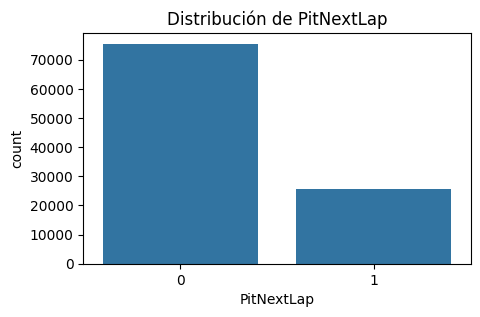

In [ ]:
plt.figure(figsize=(5, 3))
sns.countplot(x=df_f1["PitNextLap"])
plt.title("Distribución de PitNextLap")
plt.show()

La revisión de unicidad, categorías y rangos permitió validar la consistencia general de los datos y comprender mejor el comportamiento de las variables principales del proyecto.

Se confirmó que el dataset no contiene registros duplicados y que las variables presentan valores coherentes con el contexto de una carrera de Fórmula 1. Además, la exploración de la variable objetivo mostró un desbalance moderado entre las clases, donde la mayoría de las observaciones corresponden a vueltas sin parada en boxes.

El análisis también evidenció diferencias en variables como la vida útil del neumático, el tiempo de vuelta, el progreso de carrera y la degradación acumulada entre los casos con y sin parada en la siguiente vuelta, lo que sugiere que estas características podrían aportar información relevante para los modelos predictivos.

Finalmente, se identificó la necesidad de utilizar métricas robustas para evaluar los modelos de clasificación, prestando especial atención al desempeño sobre la clase minoritaria (PitNextLap = 1), debido a su importancia estratégica dentro del problema.>

In [ ]:
# Estadísticas de LapTime
q1 = df_f1["LapTime_s"].quantile(0.25)
q3 = df_f1["LapTime_s"].quantile(0.75)
iqr = q3 - q1

limite_inferior = q1 - 1.5 * iqr
limite_superior = q3 + 1.5 * iqr

print("Q1:", q1)
print("Q3:", q3)
print("IQR:", iqr)
print("Límite inferior:", limite_inferior)
print("Límite superior:", limite_superior)

# Filtrado de outliers
filas_antes = df_f1.shape[0]
df_f1 = df_f1[
    (df_f1["LapTime_s"] >= limite_inferior) &
    (df_f1["LapTime_s"] <= limite_superior)
].reset_index(drop=True)
filas_despues = df_f1.shape[0]

print("\nFilas eliminadas por outliers:", filas_antes - filas_despues)
print("Dimensión después del filtrado:", df_f1.shape)

Q1: 82.031
Q3: 99.362
IQR: 17.33099999999999
Límite inferior: 56.03450000000002
Límite superior: 125.35849999999998

Filas eliminadas por outliers: 2926
Dimensión después del filtrado: (98379, 16)


Se aplicó el método del rango intercuartílico (IQR) sobre la variable LapTime_s con el objetivo de identificar tiempos de vuelta atípicos que pudieran distorsionar el análisis y el entrenamiento de los modelos.

Los límites inferior y superior permitieron detectar registros con comportamientos inusuales respecto a la distribución general de los tiempos de vuelta. Estos valores pueden estar asociados a situaciones excepcionales de carrera, errores de medición o eventos poco representativos para el problema de predicción.

Debido a que el objetivo es modelar el comportamiento habitual de los pilotos, se decidió eliminar los registros identificados como outliers. Esto contribuye a reducir el ruido en los datos y facilita que los modelos aprendan patrones más consistentes y representativos del rendimiento en pista.

Con este proceso se obtuvo una versión más limpia del dataset, lista para continuar con el análisis exploratorio y la construcción de modelos predictivos.

##FASE 3. ANALISIS EXPLORATORIO DE DATOS

##Histogramas de variables numéricas

In [ ]:
# Variables numéricas para exploración general
numeric_cols = df_f1.select_dtypes(include=["int64", "float64"]).columns.tolist()

# Excluir el target de algunas visualizaciones globales si quieres evitar mezclarlo con el análisis general
numeric_cols_eda = [col for col in numeric_cols if col != "PitNextLap"]

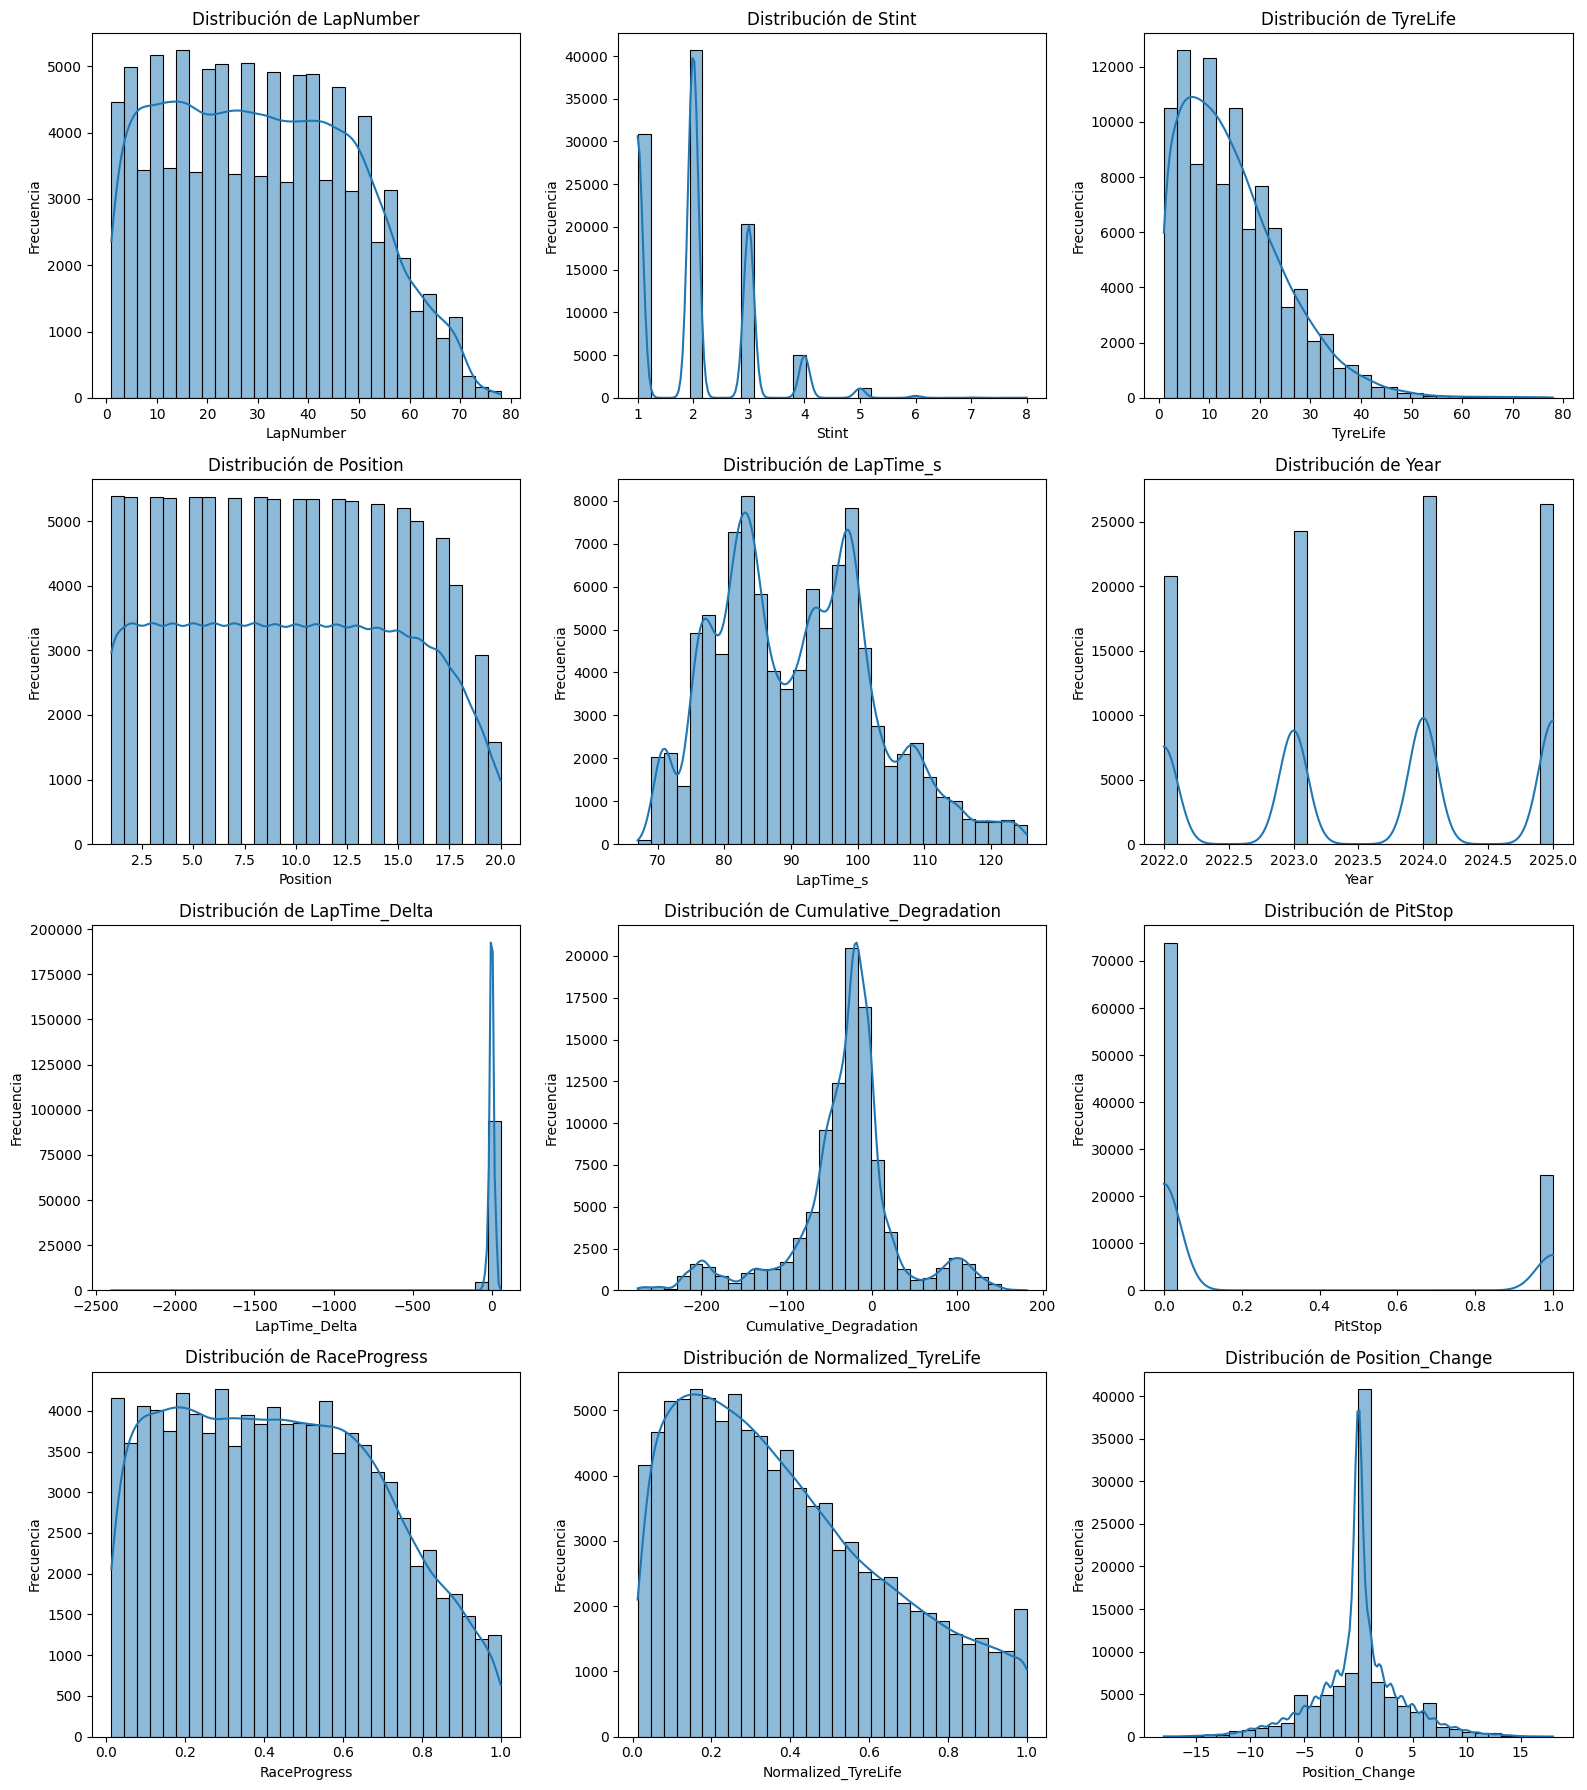

In [ ]:
n_cols = 3
n_rows = math.ceil(len(numeric_cols_eda) / n_cols)

fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(16, 4.5 * n_rows))
axes = axes.flatten()

for i, col in enumerate(numeric_cols_eda):
    sns.histplot(df_f1[col], bins=30, kde=True, ax=axes[i])
    axes[i].set_title(f"Distribución de {col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Frecuencia")

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

Los histogramas muestran que el dataset mezcla variables con comportamientos muy distintos: algunas se concentran en rangos naturales de carrera y otras tienen colas largas o sesgos marcados. Variables como TyreLife, RaceProgress y Cumulative_Degradation reflejan la evolución del stint y del desgaste, mientras que PitNextLap y PitStop confirman que las paradas son eventos menos frecuentes que las vueltas normales. Desde esta primera mirada ya se ve que no todas las variables se comportan igual, así que el análisis debía continuar revisando cada una en su propio contexto.

##Boxplots para detectar valores atípicos

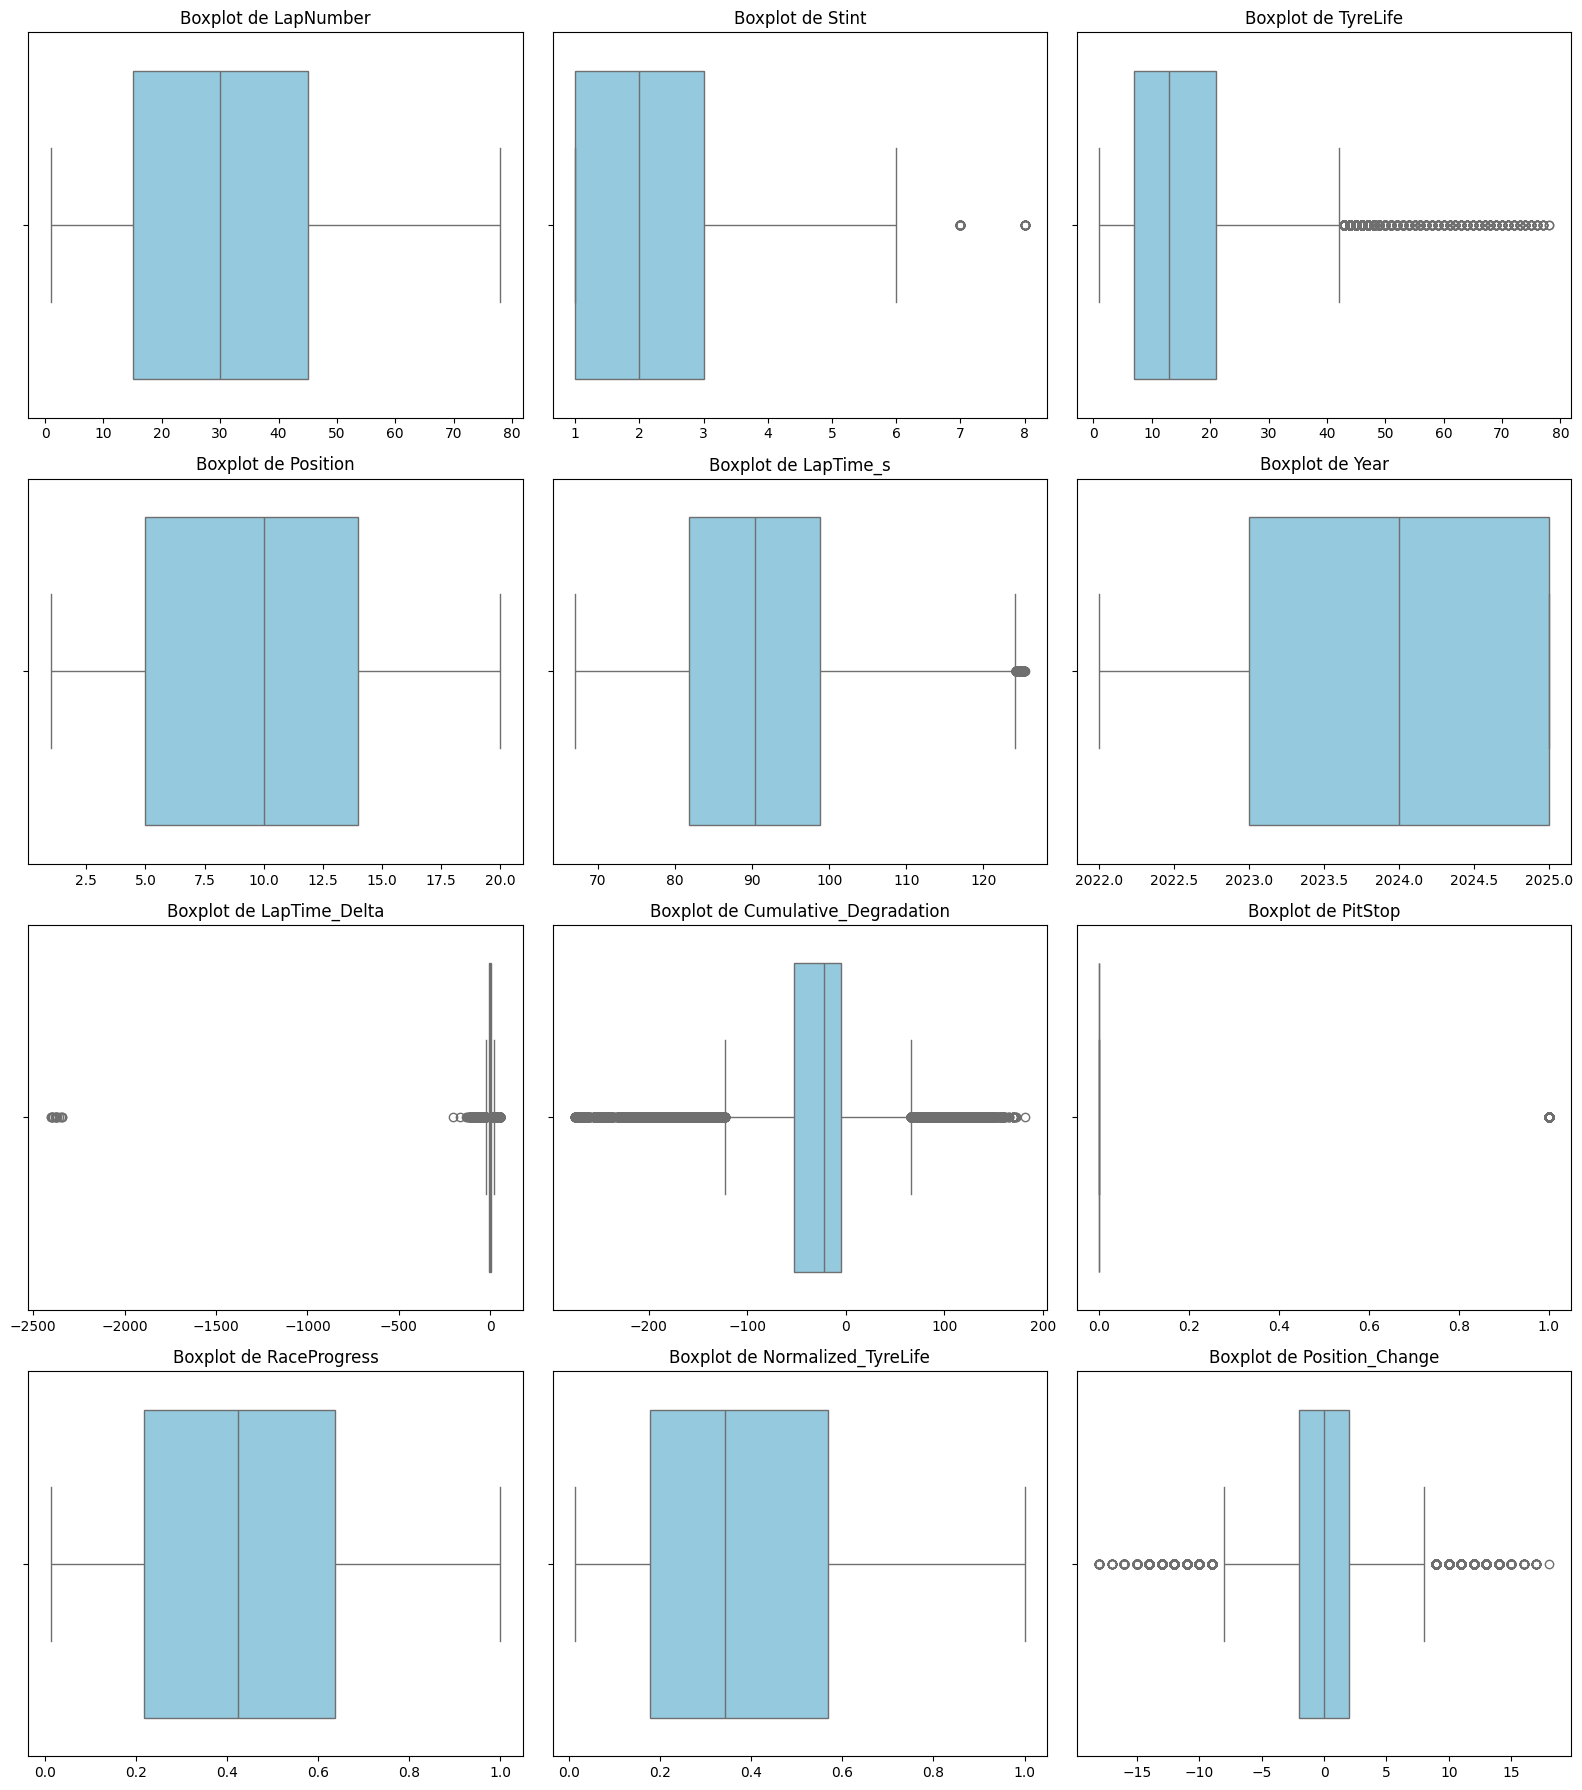

In [ ]:
n_cols = 3
n_rows = math.ceil(len(numeric_cols_eda) / n_cols)

fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(16, 4.5 * n_rows))
axes = axes.flatten()

for i, col in enumerate(numeric_cols_eda):
    sns.boxplot(x=df_f1[col], ax=axes[i], color="skyblue")
    axes[i].set_title(f"Boxplot de {col}")
    axes[i].set_xlabel("")

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

Los boxplots permitieron identificar valores extremos en varias variables, pero no todos tenían el mismo significado. En TyreLife, Stint, Cumulative_Degradation y Position_Change aparecieron extremos que sí tienen sentido dentro de la dinámica real de la Fórmula 1, así que se conservaron. En cambio, LapTime_s mostró tiempos irreales de vuelta, por lo que se espera hacer  limpieza específica, que permita disminuir ruido sin borrar información útil de carrera.

##Pit stops según número de vuelta

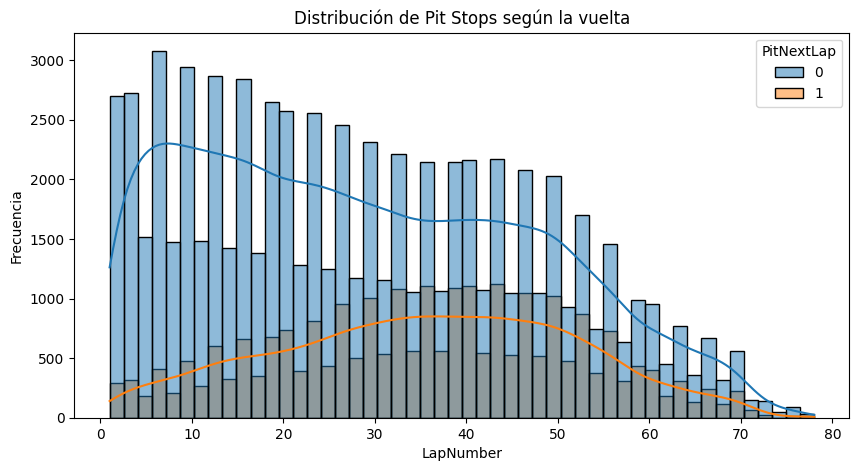

In [ ]:
plt.figure(figsize=(10, 5))
sns.histplot(data=df_f1, x="LapNumber", hue="PitNextLap", bins=50, kde=True)
plt.title("Distribución de Pit Stops según la vuelta")
plt.xlabel("LapNumber")
plt.ylabel("Frecuencia")
plt.show()

La distribución de PitNextLap a lo largo de LapNumber muestra que las paradas en boxes no ocurren de forma uniforme. Hay tramos de la carrera donde la frecuencia sube más, lo que sugiere ventanas estratégicas claras para el cambio de neumáticos. En otras palabras, el momento de carrera sí importa, y por eso LapNumber queda como una variable con señal útil para el modelado.

##Relación entre desgaste y pit stop

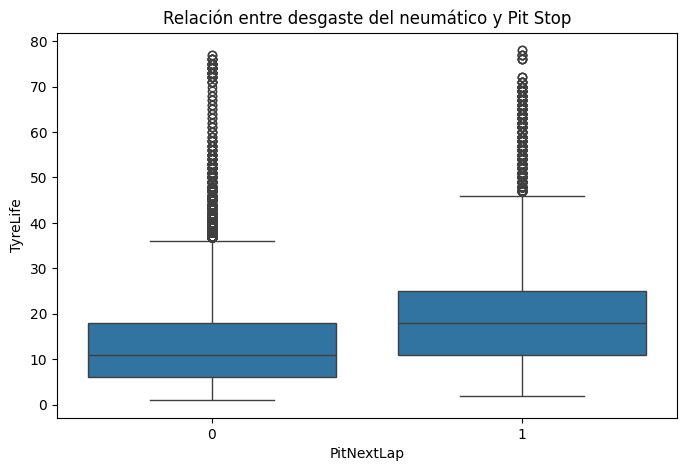

In [ ]:
plt.figure(figsize=(8, 5))
sns.boxplot(x="PitNextLap", y="TyreLife", data=df_f1)
plt.title("Relación entre desgaste del neumático y Pit Stop")
plt.xlabel("PitNextLap")
plt.ylabel("TyreLife")
plt.show()

El boxplot de TyreLife frente a PitNextLap sugiere que las paradas tienden a aparecer cuando el neumático ya acumula más vueltas y pierde vida util. No es una regla absoluta, porque existe superposición entre los grupos, pero sí se ve una tendencia clara: a mayor uso del neumático, mayor probabilidad de parar. Esto confirma que TyreLife es una señal muy relevante dentro de la lógica estratégica de carrera.

##Degradación acumulada vs pit stop

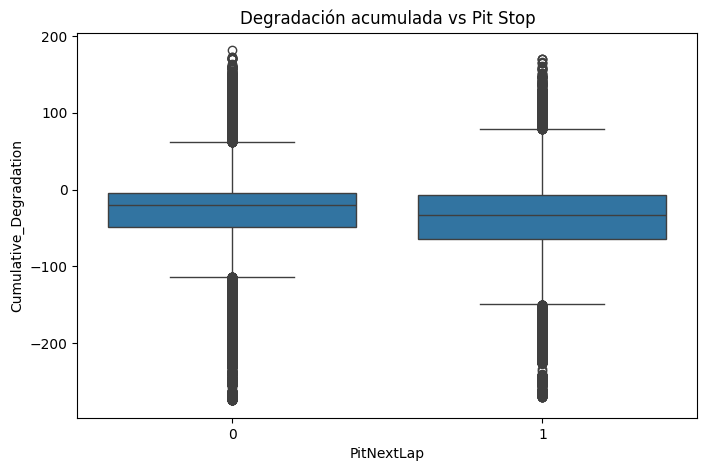

In [ ]:
plt.figure(figsize=(8, 5))
sns.boxplot(x="PitNextLap", y="Cumulative_Degradation", data=df_f1)
plt.title("Degradación acumulada vs Pit Stop")
plt.xlabel("PitNextLap")
plt.ylabel("Cumulative_Degradation")
plt.show()

La distribución de Cumulative_Degradation no muestra grandes diferencias entre quienes paran en la siguiente vuelta y quienes siguen en pista. Los valores más altos tienden a asociarse con una mayor probabilidad de pit stop, lo cual es coherente con la gestión real de neumáticos en Fórmula 1. Esta variable no explica sola la decisión, pero sí aporta información fuerte sobre el estado del neumático.

##Posición en pista vs pit stop

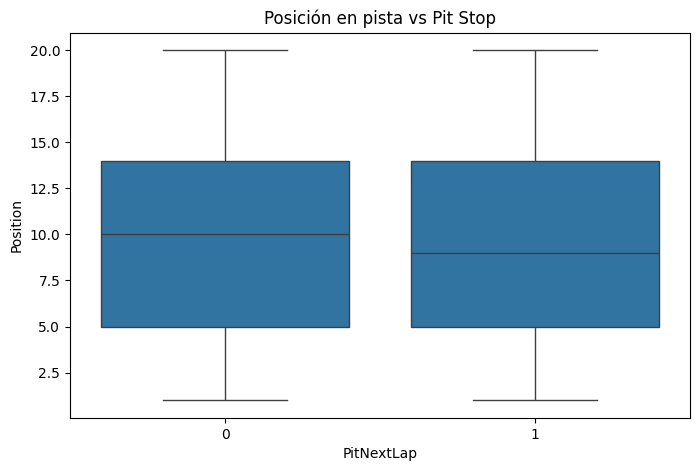

In [ ]:
plt.figure(figsize=(8, 5))
sns.boxplot(x="PitNextLap", y="Position", data=df_f1)
plt.title("Posición en pista vs Pit Stop")
plt.xlabel("PitNextLap")
plt.ylabel("Position")
plt.show()

La posición en pista también muestra diferencias entre clases, pero menos marcadas que las variables de neumáticos. Eso sugiere que Position funciona más como una variable de contexto estratégico que como un disparador directo de la parada. Es una señal útil, pero complementaria, porque por sí sola no parece explicar bien cuándo ocurre el pit stop.

##Relación entre desgaste y tiempo de vuelta

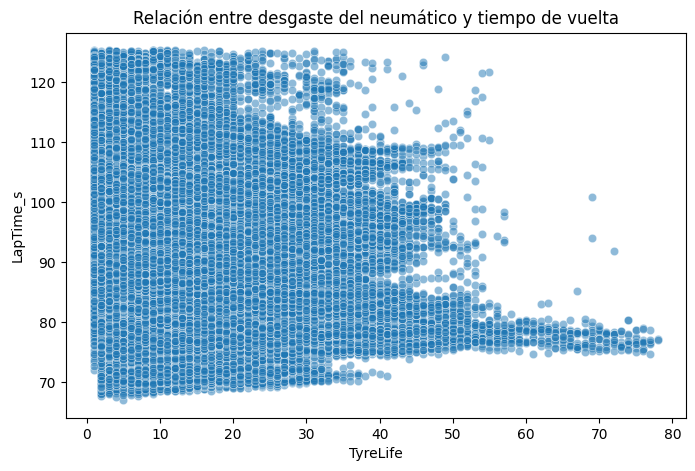

In [ ]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x="TyreLife", y="LapTime_s", data=df_f1, alpha=0.5)
plt.title("Relación entre desgaste del neumático y tiempo de vuelta")
plt.xlabel("TyreLife")
plt.ylabel("LapTime_s")
plt.show()

El gráfico de dispersión entre TyreLife y LapTime_s deja ver una nube bastante dispersa, así que no conviene leerlo como una relación perfecta. Aun así, sí se aprecia que el tiempo de vuelta cambia conforme el neumático acumula más vueltas, aunque esa relación no depende solo del desgaste. Aquí queda claro que el rendimiento en pista mezcla varios factores y no uno solo.

###Curva de rendimiento y degradación por compuesto

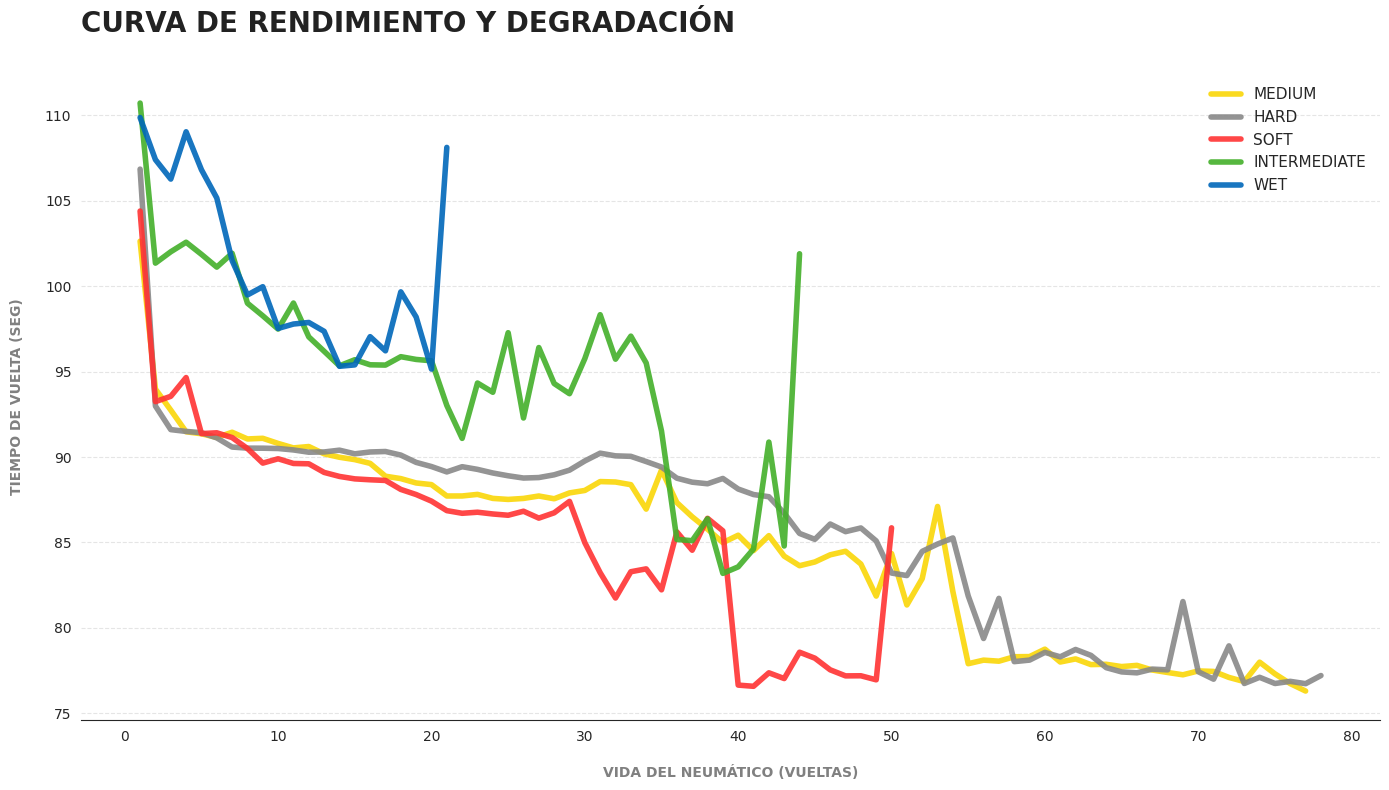

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Paleta de colores F1 (Ajustada para que el blanco no desaparezca en fondo claro)
f1_palette = {
    'SOFT': '#FF3333',
    'MEDIUM': '#FAD607',
    'HARD': '#888888',         # Cambiamos blanco por un gris elegante para fondo blanco
    'INTERMEDIATE': '#43B02A',
    'WET': '#0067B9'
}

# 2. Configuración estética de alto nivel
plt.figure(figsize=(14, 8), facecolor='white') # Fondo de la figura blanco puro
sns.set_style("white") # Estilo limpio sin cuadrícula pesada

# 3. La gráfica: Solo las líneas de tendencia (Promedio)
# El errorbar='sd' añade una sombra muy elegante que indica la dispersión sin usar puntos
ax = sns.lineplot(
    data=df_f1,
    x="TyreLife", y="LapTime_s",
    hue="Compound", palette=f1_palette,
    linewidth=4,
    errorbar=None, # Cambia a ('ci', 95) si quieres una sombra de confianza sutil
    alpha=0.9
)

# 4. "Diseño puro": Limpieza de ejes
sns.despine(left=True, bottom=False) # Quita el marco superior y derecho (y el eje Y para minimalismo)

# Añadimos líneas horizontales muy sutiles para guiar el ojo sin ensuciar
ax.yaxis.grid(True, linestyle='--', which='major', color='grey', alpha=.2)
ax.xaxis.grid(False) # Las verticales suelen sobrar en este tipo de análisis

# 5. Tipografía y etiquetas
plt.title("CURVA DE RENDIMIENTO Y DEGRADACIÓN",
          fontsize=20, fontweight='black', color='#222222', loc='left', pad=30)

plt.xlabel("VIDA DEL NEUMÁTICO (VUELTAS)", fontsize=10, fontweight='bold', color='grey', labelpad=15)
plt.ylabel("TIEMPO DE VUELTA (SEG)", fontsize=10, fontweight='bold', color='grey', labelpad=15)

# 6. Leyenda Minimalista
plt.legend(title="", frameon=False, fontsize=11, bbox_to_anchor=(1, 1))

plt.tight_layout()
plt.show()

La curva por Compound deja ver que el efecto del desgaste no es igual para todos los neumáticos. Cada compuesto sigue un comportamiento distinto a medida que aumenta TyreLife, lo que confirma que el tipo de neumático modifica la forma en que se degrada el rendimiento. Este gráfico es importante porque muestra que Compound no es solo una variable categórica más, sino una pieza central de la estrategia de carrera.

##Relación entre cambio de vuelta y rendimiento

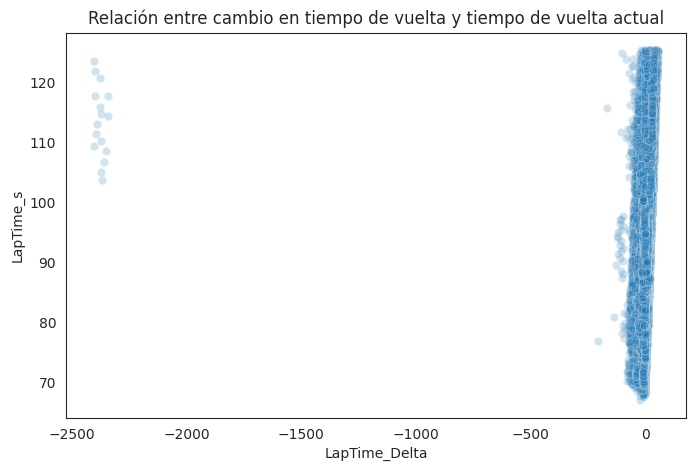

In [ ]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x="LapTime_Delta", y="LapTime_s", data=df_f1, alpha=0.2)
plt.title("Relación entre cambio en tiempo de vuelta y tiempo de vuelta actual")
plt.xlabel("LapTime_Delta")
plt.ylabel("LapTime_s")
plt.show()

La relación entre LapTime_Delta y LapTime_s presenta bastante dispersión, así que no parece haber una relación lineal fuerte. Lo que sí se observa es que la mayoría de los cambios de vuelta están cerca de cero, lo que sugiere una carrera bastante estable en condiciones normales. Los valores extremos reflejan momentos más bruscos de cambio de ritmo, que pueden estar asociados a estrategia, tráfico o degradación.

###Rango de tiempos por neumático

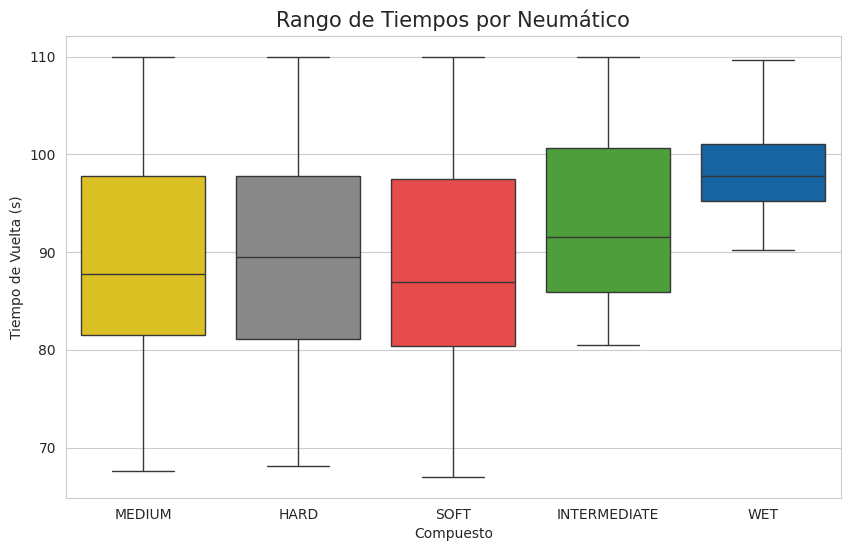

In [ ]:
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

# Un Boxplot nos dice: el tiempo promedio, los límites y los errores (puntos locos)
sns.boxplot(x="Compound", y="LapTime_s", data=df_f1[df_f1['LapTime_s'] < 110],
            palette=f1_palette, hue="Compound", legend=False)

plt.title("Rango de Tiempos por Neumático", fontsize=15)
plt.ylabel("Tiempo de Vuelta (s)")
plt.xlabel("Compuesto")
plt.show()

Al comparar Compound con LapTime_s, se observa que el rendimiento cambia según el tipo de neumático, aunque con bastante solapamiento entre grupos. Esto confirma que el compuesto sí influye en el tiempo de vuelta, pero no actúa solo: el stint, el desgaste y el contexto de carrera también modifican el resultado. Por eso esta gráfica refuerza la idea de que la estrategia de neumáticos es un problema multivariable.

###Estabilidad por compuesto

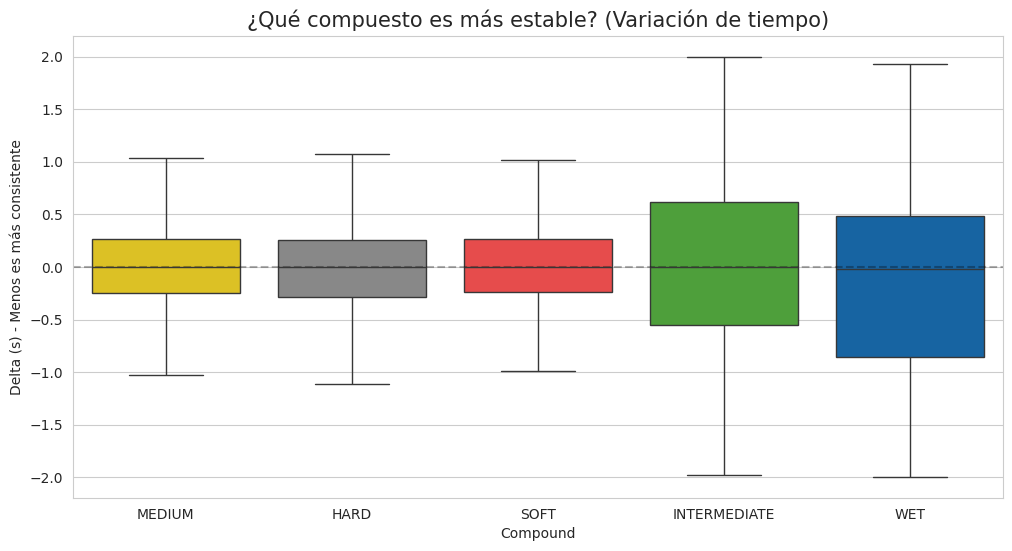

In [ ]:
plt.figure(figsize=(12, 6))

# Filtramos el Delta para evitar los Pits (solo entre -2 y 2 segundos)
df_consistencia = df_f1[(df_f1['LapTime_Delta'] > -2) & (df_f1['LapTime_Delta'] < 2)]

sns.boxplot(
    data=df_consistencia,
    x="Compound",
    y="LapTime_Delta",
    palette=f1_palette,
    hue="Compound",
    showfliers=False # Quitamos los puntitos extremos para ver la "caja" grande
)

plt.axhline(0, color='black', linestyle='--', alpha=0.3) # Referencia de vuelta perfecta
plt.title("¿Qué compuesto es más estable? (Variación de tiempo)", fontsize=15)
plt.ylabel("Delta (s) - Menos es más consistente")
plt.show()

La comparación entre Compound y LapTime_Delta sugiere que algunos neumáticos sostienen mejor la consistencia de vuelta a vuelta que otros. Esto no solo importa por velocidad, sino también por estabilidad, que en Fórmula 1 es clave para decidir cuándo conviene seguir en pista y cuándo parar. El compuesto, entonces, también afecta la regularidad del piloto.

###Zonas de rendimiento con hexbin

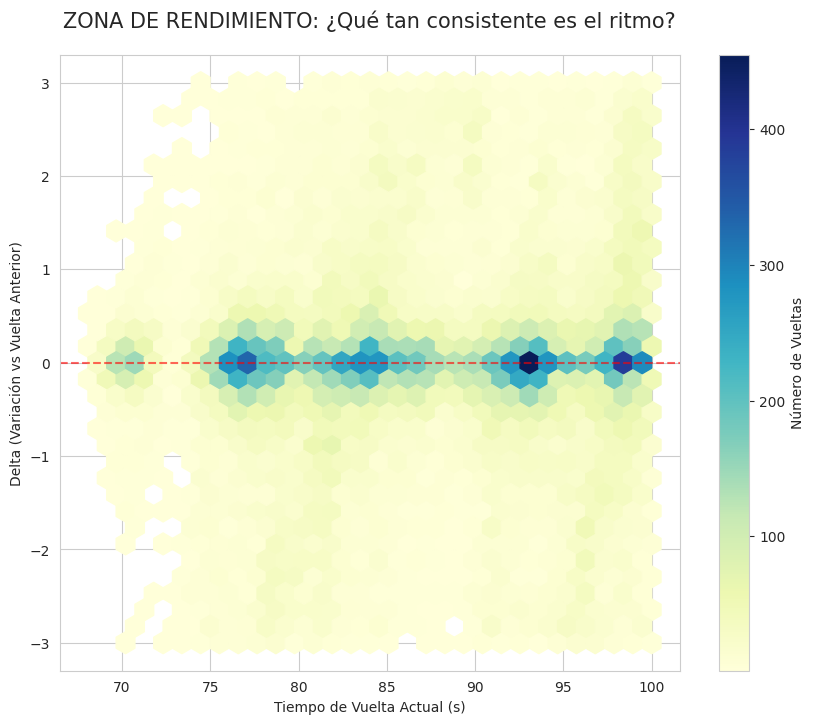

In [ ]:
# 1. Filtro ULTRA-ESTRICTO (Solo queremos vueltas de carrera, no Pits)
# El 95% de la acción real ocurre entre -3 y 3 segundos de diferencia
df_racing = df_f1[(df_f1['LapTime_Delta'] > -3) & (df_f1['LapTime_Delta'] < 3)]
# También filtramos tiempos de vuelta lógicos (ej. entre 70s y 100s)
df_racing = df_racing[(df_racing['LapTime_s'] > 65) & (df_racing['LapTime_s'] < 100)]

# 2. Configuración visual
plt.figure(figsize=(10, 8))

# 3. Usamos Hexbin: es mucho más limpio que los puntos
# Muestra dónde hay más "densidad" de vueltas
hb = plt.hexbin(df_racing['LapTime_s'], df_racing['LapTime_Delta'],
                gridsize=30, cmap='YlGnBu', mincnt=1)

# 4. Línea de referencia en el CERO (La perfección)
plt.axhline(0, color='red', linestyle='--', alpha=0.6, label="Consistencia Total")

# 5. Estética final
plt.colorbar(hb, label='Número de Vueltas')
plt.title("ZONA DE RENDIMIENTO: ¿Qué tan consistente es el ritmo?", fontsize=15, pad=20)
plt.xlabel("Tiempo de Vuelta Actual (s)")
plt.ylabel("Delta (Variación vs Vuelta Anterior)")

plt.show()

El hexbin muestra que la mayor parte de las vueltas normales se concentra en zonas de baja variación, lo que habla de un ritmo relativamente estable durante buena parte de la carrera. A la vez, aparecen puntos más extremos que representan cambios puntuales de comportamiento. Esta visualización sirve muy bien para resumir la dinámica general de la carrera sin perder la noción de dispersión.

###Matriz de correlación y resumen por clase

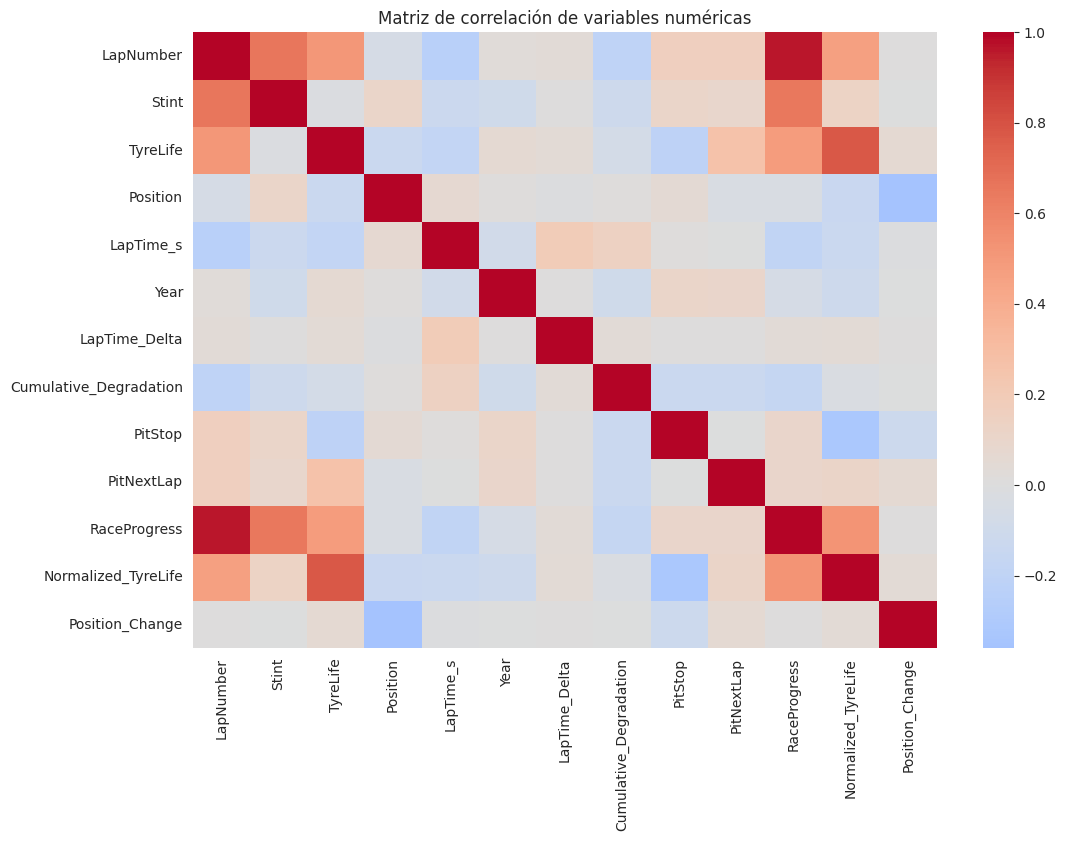

In [ ]:
plt.figure(figsize=(12, 8))
corr = df_f1.select_dtypes(include=["int64", "float64"]).corr()
sns.heatmap(corr, cmap="coolwarm", center=0, annot=
            )
plt.title("Matriz de correlación de variables numéricas")
plt.show()

Se observa una relación positiva importante entre variables asociadas al desgaste del neumático, como TyreLife, RaceProgress y Cumulative_Degradation, algo lógico ya que todas aumentan conforme avanza la carrera. También aparecen algunas relaciones inversas relacionadas con el rendimiento, donde un mayor desgaste suele asociarse con tiempos de vuelta más altos.

###Resumen estadístico por clase objetivo

In [ ]:
summary_by_target = df_f1.groupby("PitNextLap")[[
    "LapNumber",
    "TyreLife",
    "LapTime_s",
    "RaceProgress",
    "Cumulative_Degradation",
    "Position_Change",
    "LapTime_Delta"
]].agg(["mean", "median", "std"])

display(summary_by_target)

LapNumber                     TyreLife                    \
                 mean median        std       mean median        std   
PitNextLap                                                             
0           29.007952   27.0  18.401535  13.198273   11.0   9.620432   
1           35.534442   36.0  16.259146  19.361205   18.0  10.779871   

            LapTime_s                     RaceProgress  ...            \
                 mean   median        std         mean  ...       std   
PitNextLap                                              ...             
0           90.899148  90.2620  11.783435     0.421162  ...  0.268336   
1           90.840373  91.1105  11.382161     0.478045  ...  0.217280   

           Cumulative_Degradation                    Position_Change         \
                             mean  median        std            mean median   
PitNextLap                                                                    
0                      -26.247098 -20.713  60.206179       -0.139965    0.0   
1                      -45.585725 -32.692  69.956607        0.386326    0.0   

                     LapTime_Delta                    
                 std          mean median        std  
PitNextLap                                            
0           3.709700     -1.601044 -0.048  37.963462  
1           4.371212     -0.944773 -0.507  16.059885  

[2 rows x 21 columns]

Las diferencias observadas entre las clases muestran que los registros asociados a un futuro pit stop presentan características distintas respecto a los que continúan en pista.

Esto confirma que el dataset contiene señales útiles para la predicción y ayuda a entender cuáles variables parecen estar más relacionadas con las decisiones estratégicas de carrera.

##Pit Stop vs Race Progress (por etapas de carrera)

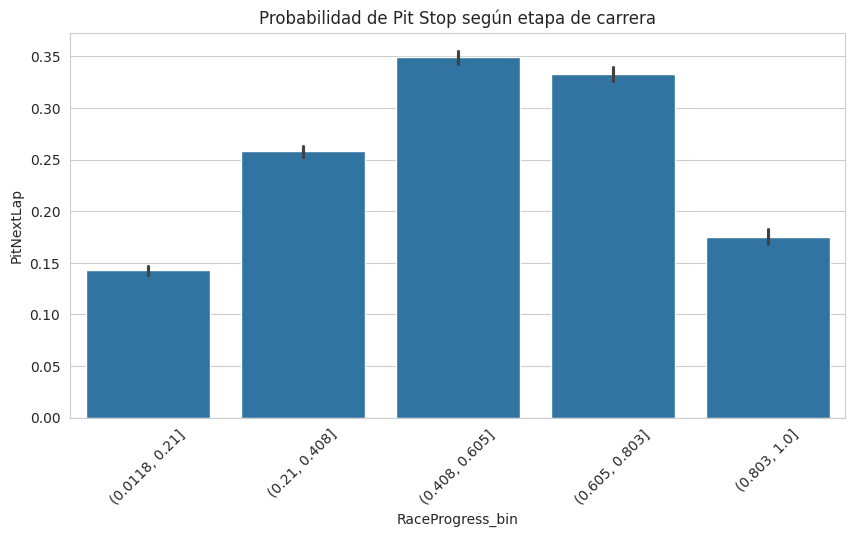

In [ ]:
# Crear bins de progreso de carrera
df_f1['RaceProgress_bin'] = pd.cut(df_f1['RaceProgress'], bins=5)

# Gráfico
plt.figure(figsize=(10,5))
sns.barplot(x='RaceProgress_bin', y='PitNextLap', data=df_f1)
plt.title('Probabilidad de Pit Stop según etapa de carrera')
plt.xticks(rotation=45)
plt.show()

La probabilidad de realizar un pit stop aumenta durante la parte media de la carrera y disminuye nuevamente hacia el final.

Este comportamiento refleja la existencia de ventanas estratégicas donde los equipos concentran la mayoría de sus decisiones de parada. La variable RaceProgress aporta, por tanto, una señal temporal importante para el modelo.

##Pit Stop vs TyreLife (desgaste por rangos)

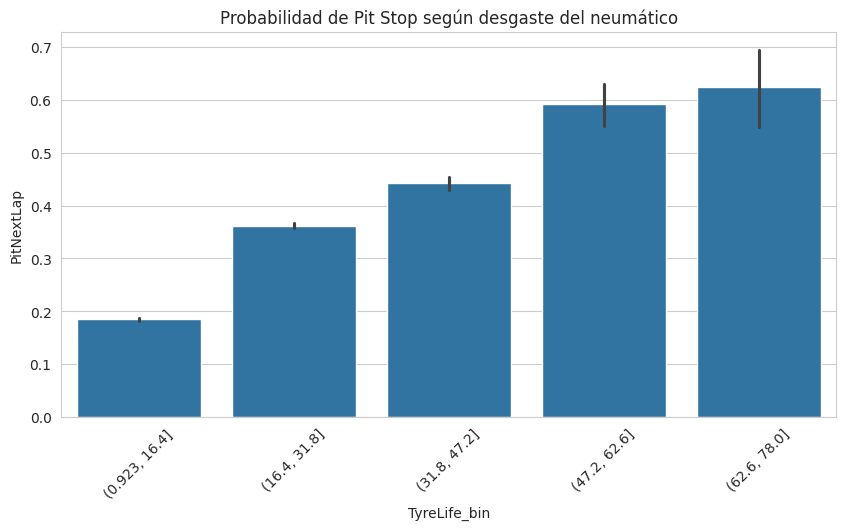

In [ ]:
# Crear bins de desgaste
df_f1['TyreLife_bin'] = pd.cut(df_f1['TyreLife'], bins=5)

plt.figure(figsize=(10,5))
sns.barplot(x='TyreLife_bin', y='PitNextLap', data=df_f1)
plt.title('Probabilidad de Pit Stop según desgaste del neumático')
plt.xticks(rotation=45)
plt.show()

Se observa un incremento casi continuo en la probabilidad de pit stop a medida que aumenta el desgaste del neumático.

Esta es una de las relaciones más claras encontradas durante el análisis exploratorio y confirma que TyreLife es una de las variables con mayor capacidad para anticipar futuras paradas en boxes.

##Pit Stop vs Compound (tipo de neumático)

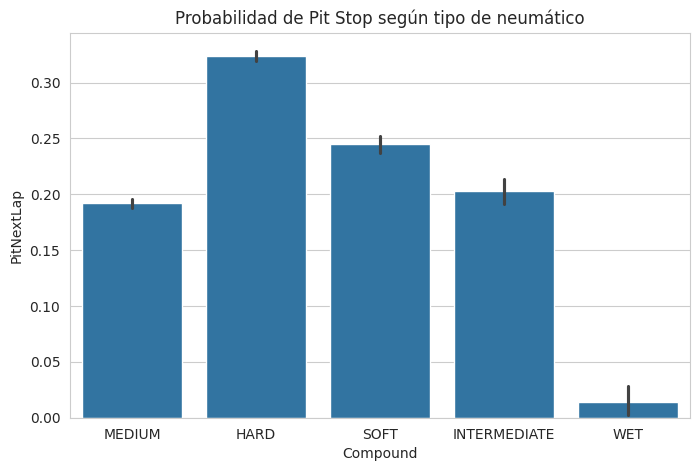

In [ ]:
plt.figure(figsize=(8,5))
sns.barplot(x='Compound', y='PitNextLap', data=df_f1)
plt.title('Probabilidad de Pit Stop según tipo de neumático')
plt.show()

La probabilidad de pit stop varía considerablemente entre compuestos, indicando que la estrategia de parada también depende del neumático utilizado.

Esto demuestra que el compuesto aporta información relevante sobre el comportamiento estratégico de los equipos y justifica su inclusión dentro de los modelos predictivos.

###Distribución del tiempo de vuelta por Compound y Stint

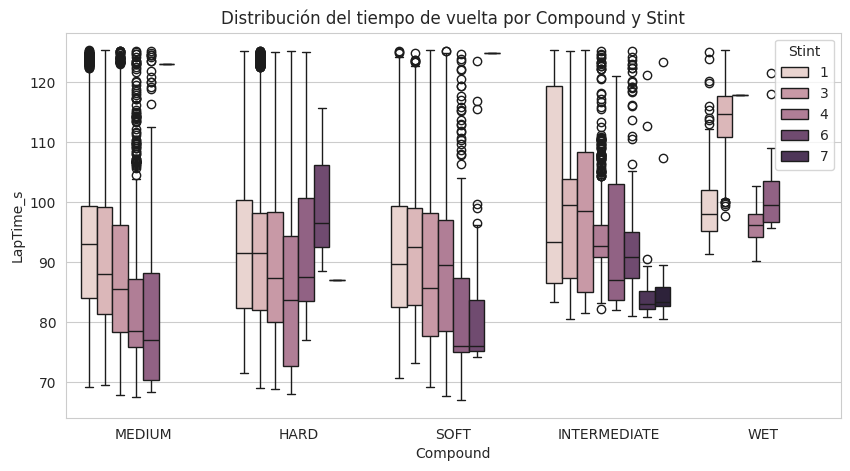

In [ ]:
plt.figure(figsize=(10,5))
sns.boxplot(x='Compound', y='LapTime_s', hue='Stint', data=df_f1)
plt.title('Distribución del tiempo de vuelta por Compound y Stint')
plt.show()

Los tiempos de vuelta cambian no solo según el compuesto utilizado, sino también según el stint en el que se encuentra el piloto.

Esto evidencia que el rendimiento depende de la combinación de múltiples factores y no de una única variable aislada. Para los modelos, este resultado refuerza la importancia de capturar interacciones entre desgaste, estrategia y contexto de carrera.

## Conclusiones del Análisis Exploratorio de Datos

El análisis exploratorio permitió entender que la estrategia de pit stop y el rendimiento por vuelta dependen de varias señales al mismo tiempo, no de una sola variable. En particular, TyreLife, Cumulative_Degradation, RaceProgress y Compound mostraron relaciones claras con la decisión de parar en boxes y con el comportamiento del tiempo de vuelta. También se observó que el efecto del desgaste cambia según el tipo de neumático y el momento de la carrera, lo que confirma que el problema tiene una dinámica estratégica y no lineal.

Además, el EDA mostró que existen variables con comportamientos similares, posibles redundancias y un desbalance moderado en la clase objetivo PitNextLap. Por eso, antes de modelar, era necesario definir con cuidado qué variables aportarían información real y cuáles debían excluirse por limpieza, redundancia o riesgo de fuga de información.

Con estas observaciones, la siguiente etapa se enfoca en formalizar el problema de predicción y preparar el dataset final para modelado. En esta fase se definirán claramente las variables objetivo, se separarán los predictores, se excluirán las columnas con posible leakage y se establecerá la base final para los modelos de clasificación y regresión.

#FASE 4. DEFINICIÓN DEL PROBLEMA Y CONTROL DE FUGA DE INFORMACIÓN

##Definición de targets y variables base

In [ ]:
# =========================
# TARGETS
# =========================
target_clf = "PitNextLap"
target_reg = "LapTime_s"

# =========================
# VARIABLES BASE DISPONIBLES
# =========================
all_features = [
    "Driver",
    "LapNumber",
    "Compound",
    "Stint",
    "TyreLife",
    "Position",
    "LapTime_s",
    "Race",
    "Year",
    "LapTime_Delta",
    "Cumulative_Degradation",
    "PitStop",
    "PitNextLap",
    "RaceProgress",
    "Normalized_TyreLife",
    "Position_Change"
]

print("Variables disponibles:", all_features)

Variables disponibles: ['Driver', 'LapNumber', 'Compound', 'Stint', 'TyreLife', 'Position', 'LapTime_s', 'Race', 'Year', 'LapTime_Delta', 'Cumulative_Degradation', 'PitStop', 'PitNextLap', 'RaceProgress', 'Normalized_TyreLife', 'Position_Change']


En esta etapa se definieron los dos problemas que abordará el proyecto. Por un lado, predecir si un piloto realizará un pit stop en la siguiente vuelta (PitNextLap) y, por otro, estimar su tiempo de vuelta (LapTime_s). A partir de estas variables objetivo se identificaron todas las características disponibles para construir los modelos.

##**Criterios de selección de variables**

No todas las variables disponibles son adecuadas para el modelado. Algunas fueron excluidas por riesgo de fuga de información, redundancia o porque podían llevar al modelo a memorizar situaciones específicas en lugar de aprender patrones generales. El objetivo fue conservar únicamente variables que aportaran información útil y realista para la predicción.

- `PitNextLap` se define como la variable objetivo de clasificación.
- `LapTime_s` se define como la variable objetivo de regresión.
- `PitStop` se excluye del conjunto de variables predictoras debido a su cercanía con el evento a predecir y al posible riesgo de fuga de información.
- `Normalized_TyreLife` se excluye del baseline para evitar redundancia con `TyreLife`, ya que ambas representan la vida útil del neumático con un alto nivel de solapamiento conceptual.
- `Driver` y `Race` se excluyen del baseline inicial por su alta cardinalidad y porque podrían introducir memorización en lugar de patrones generalizables.
- `LapTime_Delta` se mantiene para clasificación, pero se excluye para regresión, ya que está demasiado ligada al rendimiento de vuelta y podría sesgar la predicción del tiempo actual.

##Construcción de variables finales para clasificación

In [ ]:
# =========================
# VARIABLES PARA CLASIFICACIÓN
# =========================
features_clf = [
    "LapNumber",
    "Compound",
    "Stint",
    "TyreLife",
    "Position",
    "Year",
    "LapTime_Delta",
    "Cumulative_Degradation",
    "RaceProgress",
    "Position_Change"
]

df_clf_base = df_f1[features_clf + [target_clf]].copy()

print("Dimensión dataset clasificación:", df_clf_base.shape)
print("Columnas clasificación:")
print(df_clf_base.columns.tolist())

Dimensión dataset clasificación: (98379, 11)
Columnas clasificación:
['LapNumber', 'Compound', 'Stint', 'TyreLife', 'Position', 'Year', 'LapTime_Delta', 'Cumulative_Degradation', 'RaceProgress', 'Position_Change', 'PitNextLap']


Se construyó un conjunto de variables enfocado en anticipar futuras decisiones de pit stop. Las características seleccionadas describen el estado del neumático, el contexto de carrera y el rendimiento reciente del piloto, proporcionando información relevante para identificar posibles ventanas de parada.

##Construcción de variables finales para regresión

In [ ]:
# =========================
# VARIABLES PARA REGRESIÓN
# =========================
features_reg = [
    "LapNumber",
    "Compound",
    "Stint",
    "TyreLife",
    "Position",
    "Year",
    "Cumulative_Degradation",
    "RaceProgress",
    "Position_Change"
]

df_reg_base = df_f1[features_reg + [target_reg]].copy()

print("Dimensión dataset regresión:", df_reg_base.shape)
print("Columnas regresión:")
print(df_reg_base.columns.tolist())

Dimensión dataset regresión: (98379, 10)
Columnas regresión:
['LapNumber', 'Compound', 'Stint', 'TyreLife', 'Position', 'Year', 'Cumulative_Degradation', 'RaceProgress', 'Position_Change', 'LapTime_s']


In [ ]:
#listas las columnas del dataset
df_f1.columns.tolist()

['Driver',
 'LapNumber',
 'Compound',
 'Stint',
 'TyreLife',
 'Position',
 'LapTime_s',
 'Race',
 'Year',
 'LapTime_Delta',
 'Cumulative_Degradation',
 'PitStop',
 'PitNextLap',
 'RaceProgress',
 'Normalized_TyreLife',
 'Position_Change',
 'RaceProgress_bin',
 'TyreLife_bin']

## Conclusión de la fase 4
Con las variables objetivo definidas y las características seleccionadas, ya se cuenta con una versión controlada del dataset para cada problema de predicción. Esta preparación permite avanzar al modelado con una base más limpia, coherente y alineada con las condiciones reales que enfrentaría un modelo al momento de realizar predicciones.

##**FASE 5. FEATURE ENGINEERING**

##Variables de desgaste

In [ ]:
# =========================
# Vida del neumatico   RELATIVO
# =========================
df_f1["TyreWear_Ratio"] = df_f1["TyreLife"] / (df_f1["LapNumber"] + 1)

# =========================
# DESGASTE ACUMULADO NORMALIZADO
# =========================
df_f1["Degradation_per_Lap"] = df_f1["Cumulative_Degradation"] / (df_f1["TyreLife"] + 1)

Se crearon nuevas variables relacionadas con el desgaste del neumático para representar mejor su estado durante la carrera. En lugar de utilizar únicamente valores absolutos, estas métricas incorporan información relativa al avance de la prueba y a la degradación acumulada. El objetivo es ayudar al modelo a identificar situaciones donde el neumático comienza a perder rendimiento y aumenta la probabilidad de un cambio de estrategia.


##Variables de ritmo reciente

In [ ]:
# Orden correcto para series temporales
df_f1 = df_f1.sort_values(by=["Driver", "Race", "LapNumber"])

# PROMEDIO SOLO CON PASADO
df_f1["Rolling_LapTime_mean_3"] = (
    df_f1.groupby(["Driver", "Race"])["LapTime_s"]
    .shift(1)
    .rolling(window=3, min_periods=1)
    .mean()
)

# DESVIACIÓN SOLO CON PASADO
df_f1["Rolling_LapTime_std_3"] = (
    df_f1.groupby(["Driver", "Race"])["LapTime_s"]
    .shift(1)
    .rolling(window=3, min_periods=1)
    .std()
)

In [ ]:
df_f1[["Rolling_LapTime_mean_3", "Rolling_LapTime_std_3"]] = \
df_f1[["Rolling_LapTime_mean_3", "Rolling_LapTime_std_3"]].fillna(method="bfill").fillna(df_f1["Rolling_LapTime_mean_3"].median())

/tmp/ipykernel_33101/2063823973.py:2: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_f1[["Rolling_LapTime_mean_3", "Rolling_LapTime_std_3"]].fillna(method="bfill").fillna(df_f1["Rolling_LapTime_mean_3"].median())


El rendimiento de un piloto no depende únicamente de la vuelta actual, sino también de su comportamiento en vueltas anteriores. Por esta razón se construyeron variables basadas en ventanas móviles que resumen el ritmo reciente y la consistencia del piloto. Estas características permiten al modelo detectar tendencias de mejora, deterioro o estabilidad antes de tomar una decisión de predicción.

##Contexto de carrera

In [ ]:
# =========================
# Posición relativa al momento de carrera
# =========================
df_f1["Position_Pressure"] = df_f1["Position"] / df_f1["LapNumber"]

# =========================
# PROGRESO AJUSTADO POR POSICIÓN
# =========================
df_f1["Progress_Position_Interaction"] = df_f1["RaceProgress"] * df_f1["Position"]

La misma situación puede tener significados distintos dependiendo del momento de carrera en el que ocurra. Para capturar ese contexto se generaron variables que combinan posición y progreso de carrera, aportando una visión más completa de la situación estratégica del piloto. Esto permite que el modelo tenga en cuenta no solo el rendimiento, sino también el escenario competitivo en el que se desarrolla.

##Variables por stint

In [ ]:
# =========================
# EDAD DEL STINT
# =========================
df_f1["Stint_Age_Ratio"] = df_f1["TyreLife"] / (df_f1["Stint"] + 1)

# =========================
# INTENSIDAD DEL STINT
# =========================
df_f1["Stint_Intensity"] = df_f1["Cumulative_Degradation"] / (df_f1["Stint"] + 1)

El desgaste y el rendimiento no evolucionan igual en todos los stints. Por ello se construyeron variables que relacionan la vida útil del neumático y la degradación acumulada con el stint actual. Estas características ayudan a representar la etapa en la que se encuentra cada juego de neumáticos y su posible impacto sobre futuras decisiones estratégicas.

##Interacciones clave

In [ ]:
# =========================
# INTERACCIONES CLAVE
# =========================
df_f1["TyreLife_x_Progress"] = df_f1["TyreLife"] * df_f1["RaceProgress"]

df_f1["Degradation_x_LapTimeDelta"] = (
    df_f1["Cumulative_Degradation"] * df_f1["LapTime_Delta"]
)

Finalmente, se crearon variables de interacción para capturar relaciones que no son evidentes cuando cada característica se analiza por separado. Estas combinaciones permiten representar situaciones más complejas, como el efecto conjunto del desgaste y el avance de carrera o la interacción entre degradación y cambios recientes de rendimiento. Este tipo de variables suele ser especialmente útil para que los modelos identifiquen patrones más cercanos a la dinámica real de una carrera de Fórmula 1.

###Validación de nuevas features

In [ ]:
# Ver nuevas columnas creadas
new_features = [col for col in df_f1.columns if col not in all_features]
print("Nuevas features creadas:")
print(new_features)

df_f1[new_features].describe()

Nuevas features creadas:
['RaceProgress_bin', 'TyreLife_bin', 'TyreWear_Ratio', 'Degradation_per_Lap', 'Rolling_LapTime_mean_3', 'Rolling_LapTime_std_3', 'Position_Pressure', 'Progress_Position_Interaction', 'Stint_Age_Ratio', 'Stint_Intensity', 'TyreLife_x_Progress', 'Degradation_x_LapTimeDelta']


,TyreWear_Ratio,Degradation_per_Lap,Rolling_LapTime_mean_3,Rolling_LapTime_std_3,Position_Pressure,Progress_Position_Interaction,Stint_Age_Ratio,Stint_Intensity,TyreLife_x_Progress,Degradation_x_LapTimeDelta
count,98379.000000,98379.000000,98379.000000,98379.000000,98379.000000,98379.000000,98379.000000,98379.000000,98379.000000,98379.000000
mean,0.562891,-2.938505,90.919771,3.890112,0.762905,4.198386,5.287881,-9.968240,7.735010,116.961806
std,0.327784,7.818040,10.486586,5.058615,1.683773,3.610432,4.076380,25.040272,8.393662,1112.628992
min,0.013333,-120.154000,67.542000,0.000707,0.012821,0.012821,0.142857,-105.185500,0.012821,-28223.871172
25%,0.285714,-4.423542,82.966667,0.692788,0.162162,1.272727,2.250000,-17.537375,1.633803,-93.230650
50%,0.515152,-1.725968,90.320667,1.591801,0.318182,3.166667,4.333333,-6.922000,4.935897,1.393644
75%,0.888889,-0.319343,98.704667,5.066409,0.650000,6.263158,7.333333,-1.719500,11.041667,303.924701
max,4.500000,70.240500,124.760000,37.338066,20.000000,20.000000,34.500000,86.331500,78.000000,42114.427524


###Conclusión de la Fase 5

El feature engineering permitió transformar variables descriptivas en variables con mayor contexto de carrera. En lugar de analizar únicamente el estado actual del piloto o del neumático, las nuevas características incorporan información sobre desgaste, consistencia, ritmo reciente y evolución de la estrategia a lo largo de la prueba.

Estas transformaciones buscan acercar los datos a la forma en que realmente se toman decisiones en Fórmula 1, donde factores como la degradación acumulada, el momento de carrera y la estabilidad del ritmo suelen ser más relevantes que una medición aislada.

Con este enriquecimiento del dataset, los modelos disponen de una representación más completa del comportamiento en pista, aumentando su capacidad para identificar patrones asociados tanto a los pit stops como al rendimiento del piloto.

##FASE 6. Separación de datasets para cada tarea


In [ ]:
df_clf = df_clf_base.copy()
df_reg = df_reg_base.copy()

In [ ]:
features_nuevas = [
    'TyreWear_Ratio',
    'Degradation_per_Lap',
    'Rolling_LapTime_mean_3',
    'Rolling_LapTime_std_3',
    'Position_Pressure',
    'Progress_Position_Interaction',
    'Stint_Age_Ratio',
    'Stint_Intensity',
    'TyreLife_x_Progress',
    'Degradation_x_LapTimeDelta'
]

df_clf = pd.concat([df_clf, df_f1[features_nuevas]], axis=1)

In [ ]:
df_clf

,LapNumber,Compound,Stint,TyreLife,Position,Year,LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change,...,TyreWear_Ratio,Degradation_per_Lap,Rolling_LapTime_mean_3,Rolling_LapTime_std_3,Position_Pressure,Progress_Position_Interaction,Stint_Age_Ratio,Stint_Intensity,TyreLife_x_Progress,Degradation_x_LapTimeDelta
0,1,MEDIUM,1,2.0,17,2023,0.000,0.000,0.017241,0.0,...,1.000000,0.000000,100.625000,0.399515,17.000000,0.293103,1.00,0.00000,0.034483,0.000000
1,2,MEDIUM,1,3.0,18,2023,-7.065,-7.065,0.034483,-1.0,...,1.000000,-1.766250,100.524000,0.721819,9.000000,0.620690,1.50,-3.53250,0.103448,49.914225
2,3,MEDIUM,1,4.0,18,2023,-1.792,-8.857,0.051724,0.0,...,1.000000,-1.771400,101.820333,15.936332,6.000000,0.931034,2.00,-4.42850,0.206897,15.871744
3,4,MEDIUM,1,5.0,18,2023,-0.177,-9.034,0.068966,0.0,...,1.000000,-1.505667,92.589333,2.865679,4.500000,1.241379,2.50,-4.51700,0.344828,1.599018
4,5,MEDIUM,1,6.0,18,2023,-0.169,-9.203,0.086207,0.0,...,1.000000,-1.314714,90.841667,0.766012,3.600000,1.551724,3.00,-4.60150,0.517241,1.555307
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
98374,52,HARD,3,29.0,12,2022,26.850,-90.264,0.722222,2.0,...,0.547170,-3.008800,102.056333,2.324168,0.230769,8.666667,7.25,-22.56600,20.944444,-2423.588400
98375,53,HARD,3,30.0,13,2022,27.061,-88.437,0.736111,1.0,...,0.555556,-2.852806,101.712667,2.158991,0.245283,9.569444,7.50,-22.10925,22.083333,-2393.193657
98376,54,HARD,3,31.0,13,2022,27.149,-89.535,0.750000,0.0,...,0.563636,-2.797969,102.412333,2.802110,0.240741,9.750000,7.75,-22.38375,23.250000,-2430.785715
98377,55,HARD,3,32.0,14,2022,4.428,-89.825,0.763889,-1.0,...,0.571429,-2.721970,103.347667,2.981938,0.254545,10.694444,8.00,-22.45625,24.444444,-397.745100


In [ ]:
features_reg = [
    'TyreWear_Ratio',
    'Degradation_per_Lap',
    'Rolling_LapTime_mean_3',
    'Rolling_LapTime_std_3',
    'Position_Pressure',
    'Progress_Position_Interaction',
    'Stint_Age_Ratio',
    'Stint_Intensity',
    'TyreLife_x_Progress'
 ]

df_reg = pd.concat([df_reg, df_f1[features_reg]], axis=1)

In [ ]:
df_reg

,LapNumber,Compound,Stint,TyreLife,Position,Year,Cumulative_Degradation,RaceProgress,Position_Change,LapTime_s,TyreWear_Ratio,Degradation_per_Lap,Rolling_LapTime_mean_3,Rolling_LapTime_std_3,Position_Pressure,Progress_Position_Interaction,Stint_Age_Ratio,Stint_Intensity,TyreLife_x_Progress
0,1,MEDIUM,1,2.0,17,2023,0.000,0.017241,0.0,100.625,1.000000,0.000000,100.625000,0.399515,17.000000,0.293103,1.00,0.00000,0.034483
1,2,MEDIUM,1,3.0,18,2023,-7.065,0.034483,-1.0,93.560,1.000000,-1.766250,100.524000,0.721819,9.000000,0.620690,1.50,-3.53250,0.103448
2,3,MEDIUM,1,4.0,18,2023,-8.857,0.051724,0.0,91.768,1.000000,-1.771400,101.820333,15.936332,6.000000,0.931034,2.00,-4.42850,0.206897
3,4,MEDIUM,1,5.0,18,2023,-9.034,0.068966,0.0,91.591,1.000000,-1.505667,92.589333,2.865679,4.500000,1.241379,2.50,-4.51700,0.344828
4,5,MEDIUM,1,6.0,18,2023,-9.203,0.086207,0.0,91.422,1.000000,-1.314714,90.841667,0.766012,3.600000,1.551724,3.00,-4.60150,0.517241
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
98374,52,HARD,3,29.0,12,2022,-90.264,0.722222,2.0,103.373,0.547170,-3.008800,102.056333,2.324168,0.230769,8.666667,7.25,-22.56600,20.944444
98375,53,HARD,3,30.0,13,2022,-88.437,0.736111,1.0,105.200,0.555556,-2.852806,101.712667,2.158991,0.245283,9.569444,7.50,-22.10925,22.083333
98376,54,HARD,3,31.0,13,2022,-89.535,0.750000,0.0,104.102,0.563636,-2.797969,102.412333,2.802110,0.240741,9.750000,7.75,-22.38375,23.250000
98377,55,HARD,3,32.0,14,2022,-89.825,0.763889,-1.0,103.812,0.571429,-2.721970,103.347667,2.981938,0.254545,10.694444,8.00,-22.45625,24.444444


In [ ]:
drop_cols = ['RaceProgress_bin', 'TyreLife_bin']

df_clf.drop(columns=drop_cols, inplace=True, errors='ignore')
df_reg.drop(columns=drop_cols, inplace=True, errors='ignore')

In [ ]:
print("CLF shape:", df_clf.shape)
print("REG shape:", df_reg.shape)

print("\nColumnas CLF:")
print(df_clf.columns.tolist())

print("\nColumnas REG:")
print(df_reg.columns.tolist())

CLF shape: (98379, 21)
REG shape: (98379, 19)

Columnas CLF:
['LapNumber', 'Compound', 'Stint', 'TyreLife', 'Position', 'Year', 'LapTime_Delta', 'Cumulative_Degradation', 'RaceProgress', 'Position_Change', 'PitNextLap', 'TyreWear_Ratio', 'Degradation_per_Lap', 'Rolling_LapTime_mean_3', 'Rolling_LapTime_std_3', 'Position_Pressure', 'Progress_Position_Interaction', 'Stint_Age_Ratio', 'Stint_Intensity', 'TyreLife_x_Progress', 'Degradation_x_LapTimeDelta']

Columnas REG:
['LapNumber', 'Compound', 'Stint', 'TyreLife', 'Position', 'Year', 'Cumulative_Degradation', 'RaceProgress', 'Position_Change', 'LapTime_s', 'TyreWear_Ratio', 'Degradation_per_Lap', 'Rolling_LapTime_mean_3', 'Rolling_LapTime_std_3', 'Position_Pressure', 'Progress_Position_Interaction', 'Stint_Age_Ratio', 'Stint_Intensity', 'TyreLife_x_Progress']


##FASE 7. PREPROCESAMIENTO POR MODELO

El preprocesamiento de los datos se realiza de manera diferenciada para cada modelo, teniendo en cuenta los requerimientos específicos de cada algoritmo.

- Support Vector Machine (SVM) requiere que las variables numéricas estén escaladas y que las variables categóricas estén codificadas numéricamente.
- Random Forest (RF) es un modelo basado en árboles, por lo que no requiere escalado, pero sí necesita que las variables categóricas estén codificadas.

Este enfoque permite optimizar el rendimiento de cada modelo respetando su naturaleza matemática.

In [ ]:
# =========================================
# 1. SEPARAR FEATURES Y TARGET
# =========================================

X_clf = df_clf.drop(columns=["PitNextLap"])
y_clf = df_clf["PitNextLap"]

X_reg = df_reg.drop(columns=["LapTime_s"])
y_reg = df_reg["LapTime_s"]


# =========================================
# 2. TRAIN / TEST SPLIT (ANTES DE TODO)
# =========================================

from sklearn.model_selection import train_test_split

# Clasificación
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=42, stratify=y_clf
)

# Regresión
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)


# =========================================
# 3. IDENTIFICAR TIPOS DE VARIABLES
# =========================================

# Para CLASIFICACIÓN
cat_cols_clf = X_train_clf.select_dtypes(include=["object"]).columns.tolist()
num_cols_clf = X_train_clf.select_dtypes(exclude=["object"]).columns.tolist()

# Para REGRESIÓN
cat_cols_reg = X_train_reg.select_dtypes(include=["object"]).columns.tolist()
num_cols_reg = X_train_reg.select_dtypes(exclude=["object"]).columns.tolist()

In [ ]:

# =========================================
# 4. SVM — CLASIFICACIÓN
# =========================================

from sklearn.preprocessing import OneHotEncoder, StandardScaler
import pandas as pd

encoder_clf = OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore')
scaler_clf = StandardScaler()

# FIT SOLO EN TRAIN
X_train_cat_clf = encoder_clf.fit_transform(X_train_clf[cat_cols_clf])
X_test_cat_clf = encoder_clf.transform(X_test_clf[cat_cols_clf])

X_train_num_clf = scaler_clf.fit_transform(X_train_clf[num_cols_clf])
X_test_num_clf = scaler_clf.transform(X_test_clf[num_cols_clf])

# DataFrames
X_train_cat_clf_df = pd.DataFrame(
    X_train_cat_clf,
    columns=encoder_clf.get_feature_names_out(cat_cols_clf),
    index=X_train_clf.index
)

X_test_cat_clf_df = pd.DataFrame(
    X_test_cat_clf,
    columns=encoder_clf.get_feature_names_out(cat_cols_clf),
    index=X_test_clf.index
)

X_train_num_clf_df = pd.DataFrame(
    X_train_num_clf,
    columns=num_cols_clf,
    index=X_train_clf.index
)

X_test_num_clf_df = pd.DataFrame(
    X_test_num_clf,
    columns=num_cols_clf,
    index=X_test_clf.index
)

# Unión final
X_train_svm_clf = pd.concat([X_train_num_clf_df, X_train_cat_clf_df], axis=1)
X_test_svm_clf = pd.concat([X_test_num_clf_df, X_test_cat_clf_df], axis=1)

print("SVM CLF Train:", X_train_svm_clf.shape)

SVM CLF Train: (78703, 23)


In [ ]:
# =========================================
# 5. SVM — REGRESIÓN
# =========================================

encoder_reg = OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore')
scaler_reg = StandardScaler()

# FIT SOLO EN TRAIN
X_train_cat_reg = encoder_reg.fit_transform(X_train_reg[cat_cols_reg])
X_test_cat_reg = encoder_reg.transform(X_test_reg[cat_cols_reg])

X_train_num_reg = scaler_reg.fit_transform(X_train_reg[num_cols_reg])
X_test_num_reg = scaler_reg.transform(X_test_reg[num_cols_reg])

# DataFrames
X_train_cat_reg_df = pd.DataFrame(
    X_train_cat_reg,
    columns=encoder_reg.get_feature_names_out(cat_cols_reg),
    index=X_train_reg.index
)

X_test_cat_reg_df = pd.DataFrame(
    X_test_cat_reg,
    columns=encoder_reg.get_feature_names_out(cat_cols_reg),
    index=X_test_reg.index
)

X_train_num_reg_df = pd.DataFrame(
    X_train_num_reg,
    columns=num_cols_reg,
    index=X_train_reg.index
)

X_test_num_reg_df = pd.DataFrame(
    X_test_num_reg,
    columns=num_cols_reg,
    index=X_test_reg.index
)

# Unión final
X_train_svm_reg = pd.concat([X_train_num_reg_df, X_train_cat_reg_df], axis=1)
X_test_svm_reg = pd.concat([X_test_num_reg_df, X_test_cat_reg_df], axis=1)

print("SVM REG Train:", X_train_svm_reg.shape)

SVM REG Train: (78703, 21)


In [ ]:
# =========================================
# 6. RANDOM FOREST — CLASIFICACIÓN
# =========================================

X_train_rf_clf = X_train_clf.copy()
X_test_rf_clf = X_test_clf.copy()

y_train_rf_clf = y_train_clf.copy()
y_test_rf_clf = y_test_clf.copy()

# Encoding
X_train_rf_clf = pd.get_dummies(X_train_rf_clf, drop_first=True)
X_test_rf_clf = pd.get_dummies(X_test_rf_clf, drop_first=True)

# Alinear columnas
X_train_rf_clf, X_test_rf_clf = X_train_rf_clf.align(
    X_test_rf_clf, join='left', axis=1, fill_value=0
)

print("RF CLF Train:", X_train_rf_clf.shape)

RF CLF Train: (78703, 23)


In [ ]:
# =========================================
# 7. RANDOM FOREST — REGRESIÓN
# =========================================

X_train_rf_reg = X_train_reg.copy()
X_test_rf_reg = X_test_reg.copy()

y_train_rf_reg = y_train_reg.copy()
y_test_rf_reg = y_test_reg.copy()

# Encoding
X_train_rf_reg = pd.get_dummies(X_train_rf_reg, drop_first=True)
X_test_rf_reg = pd.get_dummies(X_test_rf_reg, drop_first=True)

# Alinear columnas
X_train_rf_reg, X_test_rf_reg = X_train_rf_reg.align(
    X_test_rf_reg, join='left', axis=1, fill_value=0
)

print("RF REG Train:", X_train_rf_reg.shape)

RF REG Train: (78703, 21)


#Conclusión de la Fase 7

El preprocesamiento se realizó de forma específica para cada modelo con el fin de respetar sus requerimientos y evitar sesgos durante el entrenamiento. La separación entre entrenamiento y prueba se efectuó antes de cualquier transformación, garantizando que toda la información utilizada para escalar o codificar variables proviniera únicamente del conjunto de entrenamiento.

Para los modelos SVM se aplicó codificación de variables categóricas y estandarización de variables numéricas, ya que este tipo de algoritmos es sensible a las diferencias de escala entre variables. En el caso de Random Forest, únicamente fue necesario codificar las variables categóricas, manteniendo los valores originales de las variables numéricas debido a la naturaleza basada en árboles del modelo.

Además, se reutilizaron los mismos conjuntos de entrenamiento y prueba para todos los modelos de cada tarea, asegurando comparaciones justas y consistentes durante la evaluación.

Con esta etapa finalizada, los datasets quedan completamente preparados para iniciar el entrenamiento, validación y comparación de los modelos de clasificación y regresión.

##**FASE 8. ENTRENAMIENTO DE MODELOS**


##CLASIFICACION

In [ ]:
from sklearn.svm import SVC
from sklearn.svm import LinearSVC

# Modelo
svm_clf = LinearSVC(
    C=1.0,
    class_weight="balanced",
    max_iter=5000
)

# Entrenamiento
svm_clf.fit(X_train_svm_clf, y_train_clf)

# Predicciones
y_pred_svm_clf = svm_clf.predict(X_test_svm_clf)

print("SVM Clasificación entrenado correctamente")

SVM Clasificación entrenado correctamente


In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Modelo
rf_clf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

# Entrenamiento
rf_clf.fit(X_train_rf_clf, y_train_rf_clf)

# Predicciones
y_pred_rf_clf = rf_clf.predict(X_test_rf_clf)

print("Random Forest Clasificación entrenado correctamente")

Random Forest Clasificación entrenado correctamente


Se entrenaron dos modelos para predecir la variable PitNextLap: un modelo lineal basado en máquinas de soporte vectorial (SVM) y un modelo basado en árboles de decisión mediante Random Forest. Ambos algoritmos fueron seleccionados por su capacidad para capturar distintos tipos de relaciones dentro de los datos y servir como base de comparación durante la evaluación.

##REGRESION

In [ ]:
from sklearn.svm import SVR
from sklearn.svm import LinearSVR

# Modelo
svm_reg = LinearSVR(C=1.0, random_state=42)

# Entrenamiento
svm_reg.fit(X_train_svm_reg, y_train_reg)

# Predicciones
y_pred_svm_reg = svm_reg.predict(X_test_svm_reg)

print("SVM Regresión entrenado correctamente")

SVM Regresión entrenado correctamente


In [ ]:
from sklearn.ensemble import RandomForestRegressor

# Modelo
rf_reg = RandomForestRegressor(
    n_estimators=200,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)

# Entrenamiento
rf_reg.fit(X_train_rf_reg, y_train_rf_reg)

# Predicciones
y_pred_rf_reg = rf_reg.predict(X_test_rf_reg)

print("Random Forest Regresión entrenado correctamente")

Random Forest Regresión entrenado correctamente


Para la predicción del tiempo de vuelta (LapTime_s) se entrenaron versiones de regresión de los mismos enfoques: LinearSVR y Random Forest Regressor. De esta manera, se podrán comparar tanto modelos lineales como modelos capaces de capturar relaciones no lineales presentes en la dinámica de carrera.

Con los modelos entrenados y las predicciones generadas sobre los conjuntos de prueba, el proyecto queda listo para la fase de evaluación. A partir de este punto será posible medir qué tan bien cada algoritmo logra anticipar los pit stops y estimar los tiempos de vuelta, identificando las fortalezas y limitaciones de cada enfoque.

#**FASE 9. EVALUACIÓN DE MODELOS**

##**CLASIFICACIÓN**

### SVM CLASIFICACIÓN

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

print("===== SVM CLASIFICACIÓN =====")

print("\nClassification Report:")
print(classification_report(y_test_clf, y_pred_svm_clf))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test_clf, y_pred_svm_clf))

===== SVM CLASIFICACIÓN =====

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.77      0.83     14612
           1       0.53      0.74      0.61      5064

    accuracy                           0.76     19676
   macro avg       0.71      0.75      0.72     19676
weighted avg       0.80      0.76      0.77     19676


Confusion Matrix:
[[11268  3344]
 [ 1334  3730]]


Detección de futuras paradas en boxes con SVM

El modelo SVM logró identificar una parte importante de los futuros pit stops, alcanzando una sensibilidad cercana al 74%. Esto significa que aproximadamente tres de cada cuatro paradas reales fueron detectadas correctamente antes de ocurrir.

Sin embargo, esta capacidad de detección vino acompañada de un aumento en las falsas alarmas. El modelo tendió a anticipar más pit stops de los que realmente ocurrieron, lo que redujo su precisión y generó un número considerable de predicciones incorrectas.

Desde una perspectiva estratégica, este comportamiento corresponde a un modelo conservador que prefiere advertir una posible parada antes que dejarla pasar. Aunque puede ser útil cuando el objetivo es maximizar la detección de eventos, todavía presenta limitaciones para ser utilizado como herramienta principal de predicción.

### RANDOM FOREST CLASIFICACIÓN

In [ ]:
print("===== RANDOM FOREST CLASIFICACIÓN =====")

print("\nClassification Report:")
print(classification_report(y_test_rf_clf, y_pred_rf_clf))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test_rf_clf, y_pred_rf_clf))

===== RANDOM FOREST CLASIFICACIÓN =====

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.98      0.97     14612
           1       0.94      0.85      0.90      5064

    accuracy                           0.95     19676
   macro avg       0.95      0.92      0.93     19676
weighted avg       0.95      0.95      0.95     19676


Confusion Matrix:
[[14341   271]
 [  741  4323]]


Predicción de pit stops mediante Random Forest

Random Forest obtuvo el mejor desempeño para la tarea de clasificación. Con una precisión cercana al 95% y un F1 superior a 0.90, el modelo fue capaz de identificar correctamente la gran mayoría de las decisiones de parada sin generar una cantidad excesiva de falsas alertas. El modelo acertó tanto cuando un piloto continuó en pista como cuando se encontraba próximo a ingresar a boxes. Esto demuestra que logró capturar patrones estratégicos complejos relacionados con desgaste, degradación y evolución de la carrera.

Para el contexto de negocio, este resultado indica que es posible construir sistemas capaces de anticipar decisiones de pit stop con un nivel de confiabilidad suficientemente alto para apoyar procesos de análisis, simulación o evaluación estratégica.

##**REGRESION**

###SVM REGRESIÓN

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

print("===== SVM REGRESIÓN =====")

mae_svm = mean_absolute_error(y_test_reg, y_pred_svm_reg)
rmse_svm = np.sqrt(mean_squared_error(y_test_reg, y_pred_svm_reg))
r2_svm = r2_score(y_test_reg, y_pred_svm_reg)

print(f"MAE: {mae_svm:.3f}")
print(f"RMSE: {rmse_svm:.3f}")
print(f"R2: {r2_svm:.3f}")

===== SVM REGRESIÓN =====
MAE: 2.906
RMSE: 6.416
R2: 0.701


Estimación de tiempos de vuelta con SVM

En la tarea de predicción de tiempos de vuelta, SVM mostró una mejora importante respecto a versiones anteriores del modelo. Logró explicar aproximadamente el 70% de la variabilidad observada en los datos y redujo considerablemente su error de predicción.

Aun así, el modelo continuó mostrando dificultades para representar completamente la complejidad del rendimiento en pista. Factores como degradación, estrategia, tráfico o evolución de carrera parecen generar relaciones que un modelo lineal como SVM no consigue capturar por completo.

Los resultados muestran que SVM puede ofrecer estimaciones razonables del ritmo de carrera, aunque todavía con un margen de error considerable para aplicaciones donde la precisión es crítica.

###RANDOM FOREST REGRESIÓN

In [ ]:
print("===== RANDOM FOREST REGRESIÓN =====")

mae_rf = mean_absolute_error(y_test_rf_reg, y_pred_rf_reg)
rmse_rf = np.sqrt(mean_squared_error(y_test_rf_reg, y_pred_rf_reg))
r2_rf = r2_score(y_test_rf_reg, y_pred_rf_reg)

print(f"MAE: {mae_rf:.3f}")
print(f"RMSE: {rmse_rf:.3f}")
print(f"R2: {r2_rf:.3f}")

===== RANDOM FOREST REGRESIÓN =====
MAE: 1.712
RMSE: 4.003
R2: 0.883


Predicción de rendimiento en pista con Random Forest

Random Forest volvió a posicionarse como el modelo más sólido para la tarea de regresión. Alcanzó un R² cercano a 0.88, lo que significa que logró explicar cerca del 88% de las variaciones observadas en los tiempos de vuelta.

Además, presentó un error medio absoluto cercano a 1.7 segundos, una diferencia considerablemente menor que la obtenida por SVM. Esto indica que el modelo reproduce con bastante fidelidad el comportamiento real de los pilotos a lo largo de la carrera.

Desde el punto de vista operativo, estos resultados muestran que el modelo no solo entiende cuándo podría ocurrir una parada, sino también cómo evoluciona el rendimiento del monoplaza conforme cambian las condiciones de carrera.

##Tabla resumen de métricas

In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import (
    classification_report, confusion_matrix,
    precision_score, recall_score, f1_score,
    accuracy_score, balanced_accuracy_score,
    mean_absolute_error, mean_squared_error, r2_score
)

# =========================
# CLASIFICACIÓN
# =========================
clf_results = pd.DataFrame({
    "Modelo": ["SVM", "Random Forest"],
    "Accuracy": [
        accuracy_score(y_test_clf, y_pred_svm_clf),
        accuracy_score(y_test_rf_clf, y_pred_rf_clf)
    ],
    "Balanced Accuracy": [
        balanced_accuracy_score(y_test_clf, y_pred_svm_clf),
        balanced_accuracy_score(y_test_rf_clf, y_pred_rf_clf)
    ],
    "Precision (clase 1)": [
        precision_score(y_test_clf, y_pred_svm_clf),
        precision_score(y_test_rf_clf, y_pred_rf_clf)
    ],
    "Recall (clase 1)": [
        recall_score(y_test_clf, y_pred_svm_clf),
        recall_score(y_test_rf_clf, y_pred_rf_clf)
    ],
    "F1 (clase 1)": [
        f1_score(y_test_clf, y_pred_svm_clf),
        f1_score(y_test_rf_clf, y_pred_rf_clf)
    ],
    "F1 Macro": [
        f1_score(y_test_clf, y_pred_svm_clf, average="macro"),
        f1_score(y_test_rf_clf, y_pred_rf_clf, average="macro")
    ]
})

# =========================
# REGRESIÓN
# =========================
reg_results = pd.DataFrame({
    "Modelo": ["SVM", "Random Forest"],
    "MAE": [
        mean_absolute_error(y_test_reg, y_pred_svm_reg),
        mean_absolute_error(y_test_rf_reg, y_pred_rf_reg)
    ],
    "RMSE": [
        np.sqrt(mean_squared_error(y_test_reg, y_pred_svm_reg)),
        np.sqrt(mean_squared_error(y_test_rf_reg, y_pred_rf_reg))
    ],
    "R2": [
        r2_score(y_test_reg, y_pred_svm_reg),
        r2_score(y_test_rf_reg, y_pred_rf_reg)
    ]
})

print("=== CLASIFICACIÓN ===")
display(clf_results)

print("=== REGRESIÓN ===")
display(reg_results)

=== CLASIFICACIÓN ===


,Modelo,Accuracy,Balanced Accuracy,Precision (clase 1),Recall (clase 1),F1 (clase 1),F1 Macro
0,SVM,0.762248,0.753859,0.527283,0.736572,0.614599,0.721351
1,Random Forest,0.948567,0.917563,0.941010,0.853673,0.895216,0.930568


=== REGRESIÓN ===


,Modelo,MAE,RMSE,R2
0,SVM,2.905592,6.416226,0.700637
1,Random Forest,1.712305,4.002913,0.883482


#Caracteristicas Importantes

In [ ]:
importances = pd.Series(
    rf_clf.feature_importances_,
    index=X_train_rf_clf.columns
).sort_values(ascending=False)

importances.head(15)

,0
TyreWear_Ratio,0.139509
Year,0.081521
LapTime_Delta,0.070320
Stint,0.068030
Degradation_x_LapTimeDelta,0.058185
TyreLife,0.049152
Stint_Intensity,0.047724
RaceProgress,0.047099
Cumulative_Degradation,0.045967
Position_Change,0.043727


La comparación directa muestra una diferencia clara entre ambos enfoques. Mientras SVM logra capturar patrones generales, Random Forest domina tanto en clasificación como en regresión.

La mejora no es marginal: el modelo basado en árboles detecta muchos más pit stops reales y además reduce a más de la mitad el error en la predicción de tiempos de vuelta. Esto confirma que la estrategia y el rendimiento en Fórmula 1 dependen de relaciones complejas que no siempre siguen patrones lineales.

###Curvas ROC y Precision–Recall

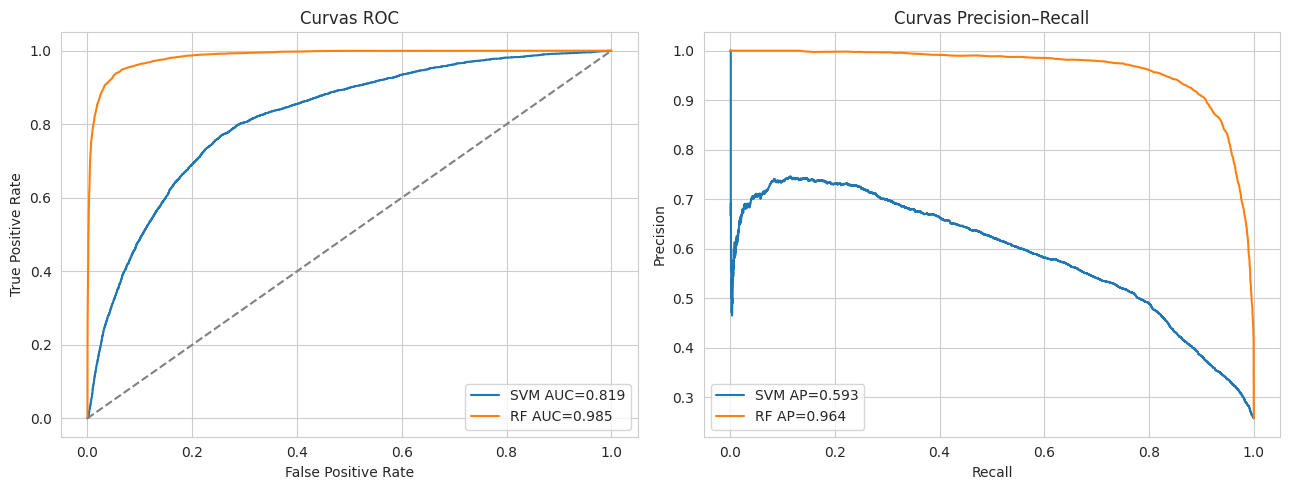

In [ ]:
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score

def get_score(model, X):
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X)[:, 1]
    elif hasattr(model, "decision_function"):
        return model.decision_function(X)
    else:
        return model.predict(X)

# Scores
score_svm = get_score(svm_clf, X_test_svm_clf)
score_rf = get_score(rf_clf, X_test_rf_clf)

# ROC
fpr_svm, tpr_svm, _ = roc_curve(y_test_clf, score_svm)
fpr_rf, tpr_rf, _ = roc_curve(y_test_rf_clf, score_rf)

roc_auc_svm = auc(fpr_svm, tpr_svm)
roc_auc_rf = auc(fpr_rf, tpr_rf)

# PR
prec_svm, rec_svm, _ = precision_recall_curve(y_test_clf, score_svm)
prec_rf, rec_rf, _ = precision_recall_curve(y_test_rf_clf, score_rf)

ap_svm = average_precision_score(y_test_clf, score_svm)
ap_rf = average_precision_score(y_test_rf_clf, score_rf)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ROC
axes[0].plot(fpr_svm, tpr_svm, label=f"SVM AUC={roc_auc_svm:.3f}")
axes[0].plot(fpr_rf, tpr_rf, label=f"RF AUC={roc_auc_rf:.3f}")
axes[0].plot([0, 1], [0, 1], linestyle="--", color="gray")
axes[0].set_title("Curvas ROC")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].legend()

# PR
axes[1].plot(rec_svm, prec_svm, label=f"SVM AP={ap_svm:.3f}")
axes[1].plot(rec_rf, prec_rf, label=f"RF AP={ap_rf:.3f}")
axes[1].set_title("Curvas Precision–Recall")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].legend()

plt.tight_layout()
plt.show()

Estas curvas permiten medir qué tan bien distingue el modelo entre una vuelta normal y una vuelta que precede a un pit stop. La separación obtenida por Random Forest es notablemente superior, lo que indica que el modelo no solo acierta cuando toma una decisión, sino que también mantiene un buen equilibrio entre detectar pit stops reales y evitar falsas alarmas.

###Comparación visual de regresión

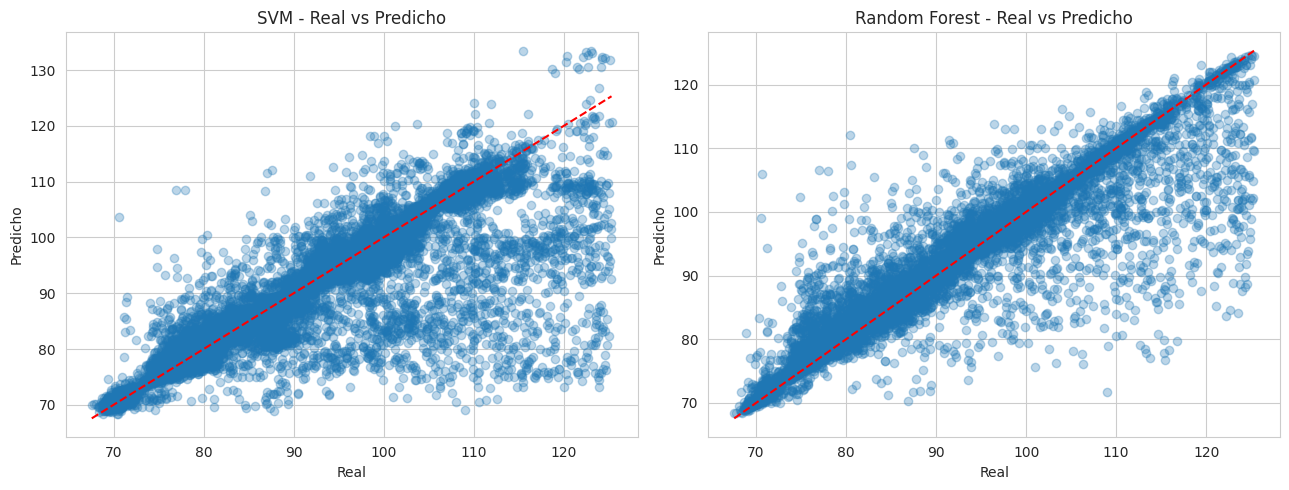

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# SVM
axes[0].scatter(y_test_reg, y_pred_svm_reg, alpha=0.3)
axes[0].plot([y_test_reg.min(), y_test_reg.max()], [y_test_reg.min(), y_test_reg.max()], linestyle="--", color="red")
axes[0].set_title("SVM - Real vs Predicho")
axes[0].set_xlabel("Real")
axes[0].set_ylabel("Predicho")

# RF
axes[1].scatter(y_test_rf_reg, y_pred_rf_reg, alpha=0.3)
axes[1].plot([y_test_rf_reg.min(), y_test_rf_reg.max()], [y_test_rf_reg.min(), y_test_rf_reg.max()], linestyle="--", color="red")
axes[1].set_title("Random Forest - Real vs Predicho")
axes[1].set_xlabel("Real")
axes[1].set_ylabel("Predicho")

plt.tight_layout()
plt.show()

Al comparar tiempos reales contra tiempos predichos, se observa que RF sigue mucho más de cerca la línea ideal de predicción.

En lenguaje de carrera, significa que el modelo entiende mejor cuándo un piloto está rodando rápido, cuándo empieza a perder rendimiento y cómo evoluciona su ritmo a lo largo del stint. SVM captura la tendencia general, pero con una dispersión considerablemente mayor.

###Residuales

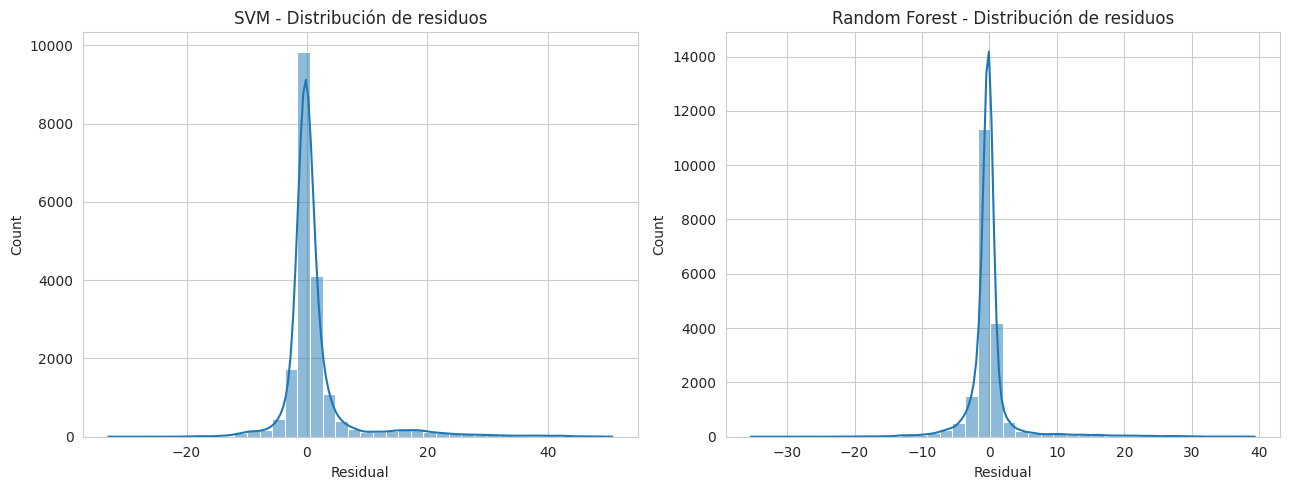

In [ ]:
res_svm = y_test_reg - y_pred_svm_reg
res_rf = y_test_rf_reg - y_pred_rf_reg

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.histplot(res_svm, bins=40, kde=True, ax=axes[0])
axes[0].set_title("SVM - Distribución de residuos")
axes[0].set_xlabel("Residual")

sns.histplot(res_rf, bins=40, kde=True, ax=axes[1])
axes[1].set_title("Random Forest - Distribución de residuos")
axes[1].set_xlabel("Residual")

plt.tight_layout()
plt.show()

En RF los errores se concentran mucho más cerca de cero, señal de que la mayoría de las predicciones se encuentran próximas al valor real. Los errores grandes existen, pero son menos frecuentes. Esto es una señal positiva porque indica que el modelo no solo es preciso en promedio, sino también más consistente a lo largo de distintas situaciones de carrera.

#**Conclusiones de la evaluación de modelos**

La fase de evaluación permitió comprobar que las variables construidas durante el proceso de ingeniería de características lograron capturar de forma efectiva los patrones estratégicos y operativos presentes en una carrera de Fórmula 1. Tanto en clasificación como en regresión, los modelos fueron capaces de extraer información relevante sobre el comportamiento de los pilotos, el desgaste de neumáticos y la evolución del rendimiento a lo largo de la carrera.

En la tarea de clasificación, orientada a predecir si un piloto realizará una parada en pits en la siguiente vuelta, se observaron diferencias significativas entre los algoritmos evaluados. El modelo SVM alcanzó un F1 Score de 0.61 para la clase de interés y un recall de 73.7%, demostrando una mayor sensibilidad para detectar posibles paradas, aunque a costa de generar una cantidad considerable de falsas alarmas. Desde una perspectiva de negocio, este comportamiento puede resultar útil cuando el objetivo es minimizar el riesgo de no anticipar una parada estratégica, incluso aceptando algunas predicciones incorrectas.

Por su parte, Random Forest obtuvo un desempeño sobresaliente, alcanzando una precisión del 94.1%, un recall del 85.4% y un F1 Score cercano al 90% para la clase positiva. Esto significa que el modelo no solo identifica correctamente la mayoría de las paradas en pits, sino que además reduce significativamente los errores de clasificación. En términos prácticos, el sistema logra anticipar con alta confiabilidad las decisiones estratégicas de carrera, convirtiéndose en una herramienta potencialmente valiosa para simulaciones, análisis de estrategias y apoyo a la toma de decisiones.

En la tarea de regresión, enfocada en la predicción del tiempo de vuelta, ambos modelos mostraron capacidad predictiva, aunque nuevamente Random Forest presentó una ventaja clara. El modelo SVM explicó aproximadamente el 70% de la variabilidad observada en los tiempos de vuelta (R² = 0.70) y registró un error medio absoluto cercano a los 2.9 segundos por vuelta. Aunque estos resultados son aceptables para una aproximación inicial, todavía existe una diferencia relevante entre los tiempos reales y los estimados.

Random Forest alcanzó un R² de 0.88, logrando explicar cerca del 88% de la variación presente en los datos y reduciendo el error medio absoluto a aproximadamente 1.7 segundos por vuelta. Considerando la alta sensibilidad que existe en Fórmula 1 respecto a diferencias de tiempo incluso inferiores a un segundo, este nivel de precisión representa un resultado notable y confirma que el modelo logró capturar gran parte de los factores que influyen en el ritmo de carrera.

El análisis de importancia de variables aportó además una visión estratégica sobre los factores que más influyen en las decisiones y el rendimiento dentro de una carrera. Variables como TyreWear_Ratio, LapTime_Delta, Stint, TyreLife, RaceProgress y las métricas de degradación acumulada se posicionaron entre las más relevantes del modelo. Esto confirma que el desgaste de neumáticos, la evolución del stint y la pérdida progresiva de rendimiento son elementos determinantes tanto para explicar los tiempos de vuelta como para anticipar decisiones de parada en pits.

Desde una perspectiva analítica, los resultados también validan la efectividad del proceso de feature engineering realizado previamente. Las variables derivadas no solo incrementaron la capacidad predictiva de los modelos, sino que además permitieron representar de manera más realista fenómenos propios de la Fórmula 1 que no estaban explícitamente contenidos en las variables originales del dataset.

En conjunto, la evidencia obtenida durante la evaluación demuestra que Random Forest constituye la alternativa más sólida para ambas tareas del proyecto, ofreciendo el mejor equilibrio entre precisión, capacidad de generalización e interpretabilidad. Los resultados alcanzados permiten concluir que es posible modelar con un alto grado de confianza tanto las estrategias de parada como el rendimiento por vuelta utilizando información histórica de carrera, generando una base robusta para aplicaciones de analítica deportiva, simulación estratégica y apoyo a la toma de decisiones en entornos competitivos de alto rendimiento.

# **OPTIMIZACIÓN Y VALIDACIÓN AVANZADA**

In [ ]:
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC

# =====================
# RANDOM FOREST
# =====================

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_scores = cross_val_score(
    rf_model,
    X_train_rf_clf,
    y_train_rf_clf,
    cv=3,
    scoring='f1'
)

print("RF F1 CV:", rf_scores)
print("RF F1 promedio:", rf_scores.mean())


# =====================
# SVM
# =====================

svm_model = LinearSVC(
    C=1.0,
    class_weight='balanced',
    max_iter=10000
)

svm_scores = cross_val_score(
    svm_model,
    X_train_svm_clf,
    y_train_clf,
    cv=3,
    scoring='f1'
)

print("SVM F1 CV:", svm_scores)
print("SVM F1 promedio:", svm_scores.mean())

RF F1 CV: [0.86464583 0.86105492 0.86349848]
RF F1 promedio: 0.8630664142701141
SVM F1 CV: [0.60772596 0.60714945 0.61341418]
SVM F1 promedio: 0.6094298624162036


###CROSS VALIDATION

In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier

# =========================
# TRANSFORMACIONES
# =========================

preprocess_svm = ColumnTransformer([
    ("num", StandardScaler(), num_cols_clf),
    ("cat", OneHotEncoder(drop='first', handle_unknown='ignore'), cat_cols_clf)
])

preprocess_rf = ColumnTransformer([
    ("cat", OneHotEncoder(drop='first', handle_unknown='ignore'), cat_cols_clf)
], remainder='passthrough')


# =========================
# PIPELINES
# =========================

pipeline_svm = Pipeline([
    ("prep", preprocess_svm),
    ("model", LinearSVC(C=1.0, max_iter=10000))
])

pipeline_rf = Pipeline([
    ("prep", preprocess_rf),
    ("model", RandomForestClassifier(n_estimators=150, random_state=42, n_jobs=-1))
])


# =========================
# CROSS VALIDATION
# =========================

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

svm_cv = cross_validate(
    pipeline_svm,
    X_train_clf,
    y_train_clf,
    cv=cv,
    scoring=["f1", "balanced_accuracy"],
    n_jobs=-1
)

rf_cv = cross_validate(
    pipeline_rf,
    X_train_clf,
    y_train_clf,
    cv=cv,
    scoring=["f1", "balanced_accuracy"],
    n_jobs=-1
)


print("===== SVM CV =====")
print("F1:", svm_cv["test_f1"].mean())
print("Balanced Acc:", svm_cv["test_balanced_accuracy"].mean())

print("\n===== RF CV =====")
print("F1:", rf_cv["test_f1"].mean())
print("Balanced Acc:", rf_cv["test_balanced_accuracy"].mean())

===== SVM CV =====
F1: 0.4863019016373746
Balanced Acc: 0.6582402238754913

===== RF CV =====
F1: 0.8616534891496034
Balanced Acc: 0.8956419910687012


###BALANCEO

In [ ]:
pipeline_svm_balanced = Pipeline([
    ("prep", preprocess_svm),
    ("model", LinearSVC(C=1.0, class_weight='balanced', max_iter=10000))
])

svm_bal_cv = cross_validate(
    pipeline_svm_balanced,
    X_train_clf,
    y_train_clf,
    cv=cv,
    scoring=["f1", "recall"],
    n_jobs=-1
)

print("===== SVM BALANCEADO =====")
print("F1:", svm_bal_cv["test_f1"].mean())
print("Recall:", svm_bal_cv["test_recall"].mean())

===== SVM BALANCEADO =====
F1: 0.6090530594250061
Recall: 0.7311142819985946


###FEATURE IMPORTANCE

In [ ]:
#rf_temp = RandomForestClassifier(n_estimators=150, random_state=42, n_jobs=-1)

#rf_temp.fit(X_train_rf_clf, y_train_rf_clf)

#importances = pd.Series(rf_temp.feature_importances_, index=X_train_rf_clf.columns)
#importances = importances.sort_values(ascending=False)

print(importances.head(25))

TyreWear_Ratio                   0.139509
Year                             0.081521
LapTime_Delta                    0.070320
Stint                            0.068030
Degradation_x_LapTimeDelta       0.058185
TyreLife                         0.049152
Stint_Intensity                  0.047724
RaceProgress                     0.047099
Cumulative_Degradation           0.045967
Position_Change                  0.043727
Stint_Age_Ratio                  0.043055
Rolling_LapTime_mean_3           0.042776
TyreLife_x_Progress              0.040555
Degradation_per_Lap              0.037498
LapNumber                        0.036942
Progress_Position_Interaction    0.035857
Position_Pressure                0.032791
Rolling_LapTime_std_3            0.031339
Position                         0.023879
Compound_SOFT                    0.010571
Compound_MEDIUM                  0.010292
Compound_INTERMEDIATE            0.003078
Compound_WET                     0.000133
dtype: float64


##**hiperparametros - GridSearch**

In [ ]:
# =========================================
# FASE 10.2 — GRID SEARCH LIGERO
# =========================================

import numpy as np
import pandas as pd

from sklearn.model_selection import GridSearchCV, StratifiedKFold, KFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.svm import LinearSVC, LinearSVR
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, balanced_accuracy_score,
    precision_score, recall_score, f1_score,
    mean_absolute_error, mean_squared_error, r2_score
)

# =========================================
# 1. SUBMUESTRAS PARA HACER EL GRID MÁS RÁPIDO
# =========================================
X_tune_clf, _, y_tune_clf, _ = train_test_split(
    X_train_clf,
    y_train_clf,
    train_size=min(20000, len(X_train_clf)),
    random_state=42,
    stratify=y_train_clf
)

X_tune_reg, _, y_tune_reg, _ = train_test_split(
    X_train_reg,
    y_train_reg,
    train_size=min(20000, len(X_train_reg)),
    random_state=42
)

# =========================================
# 2. COLS CATEGÓRICAS Y NUMÉRICAS
# =========================================
cat_cols_clf = X_train_clf.select_dtypes(include=["object"]).columns.tolist()
num_cols_clf = X_train_clf.select_dtypes(exclude=["object"]).columns.tolist()

cat_cols_reg = X_train_reg.select_dtypes(include=["object"]).columns.tolist()
num_cols_reg = X_train_reg.select_dtypes(exclude=["object"]).columns.tolist()

# =========================================
# 3. PREPROCESADORES
# =========================================
preprocess_svm_clf = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols_clf),
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), cat_cols_clf),
    ],
    remainder="drop"
)

preprocess_rf_clf = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), cat_cols_clf),
    ],
    remainder="passthrough"
)

preprocess_svm_reg = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols_reg),
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), cat_cols_reg),
    ],
    remainder="drop"
)

preprocess_rf_reg = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), cat_cols_reg),
    ],
    remainder="passthrough"
)

# =========================================
# 4. PIPES BASE
# =========================================
pipe_svm_clf = Pipeline([
    ("prep", preprocess_svm_clf),
    ("model", LinearSVC(max_iter=10000))
])

pipe_rf_clf = Pipeline([
    ("prep", preprocess_rf_clf),
    ("model", RandomForestClassifier(random_state=42, n_jobs=-1))
])

pipe_svm_reg = Pipeline([
    ("prep", preprocess_svm_reg),
    ("model", LinearSVR(max_iter=20000, random_state=42))
])

pipe_rf_reg = Pipeline([
    ("prep", preprocess_rf_reg),
    ("model", RandomForestRegressor(random_state=42, n_jobs=-1))
])

# =========================================
# 5. GRIDS PEQUEÑOS
# =========================================
grid_svm_clf = {
    "model__C": [0.25, 0.5, 1.0, 2.0],
    "model__class_weight": [None, "balanced"]
}

grid_rf_clf = {
    "model__n_estimators": [120, 200],
    "model__max_depth": [None, 15],
    "model__min_samples_leaf": [1, 3],
    "model__class_weight": [None, "balanced_subsample"]
}

grid_svm_reg = {
    "model__C": [0.25, 0.5, 1.0, 2.0],
    "model__epsilon": [0.0, 0.1, 0.2]
}

grid_rf_reg = {
    "model__n_estimators": [120, 200],
    "model__max_depth": [None, 15],
    "model__min_samples_leaf": [1, 3]
}

# =========================================
# 6. CV
# =========================================
cv_clf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
cv_reg = KFold(n_splits=3, shuffle=True, random_state=42)

# =========================================
# 7. GRIDSEARCH CLASIFICACIÓN - SVM
# =========================================
gs_svm_clf = GridSearchCV(
    estimator=pipe_svm_clf,
    param_grid=grid_svm_clf,
    scoring="f1",
    cv=cv_clf,
    n_jobs=-1,
    verbose=1
)
gs_svm_clf.fit(X_tune_clf, y_tune_clf)

print("Mejores parámetros SVM Clasificación:", gs_svm_clf.best_params_)
print("Mejor F1 CV SVM Clasificación:", gs_svm_clf.best_score_)

# Reentrenar con mejor configuración sobre todo el train
best_svm_clf = gs_svm_clf.best_estimator_
best_svm_clf.fit(X_train_clf, y_train_clf)

y_pred_svm_clf_tuned = best_svm_clf.predict(X_test_clf)

print("\n===== SVM CLASIFICACIÓN TUNED =====")
print(classification_report(y_test_clf, y_pred_svm_clf_tuned))
print(confusion_matrix(y_test_clf, y_pred_svm_clf_tuned))

# =========================================
# 8. GRIDSEARCH CLASIFICACIÓN - RF
# =========================================
gs_rf_clf = GridSearchCV(
    estimator=pipe_rf_clf,
    param_grid=grid_rf_clf,
    scoring="f1",
    cv=cv_clf,
    n_jobs=-1,
    verbose=1
)
gs_rf_clf.fit(X_tune_clf, y_tune_clf)

print("Mejores parámetros RF Clasificación:", gs_rf_clf.best_params_)
print("Mejor F1 CV RF Clasificación:", gs_rf_clf.best_score_)

best_rf_clf = gs_rf_clf.best_estimator_
best_rf_clf.fit(X_train_clf, y_train_clf)

y_pred_rf_clf_tuned = best_rf_clf.predict(X_test_clf)

print("\n===== RF CLASIFICACIÓN TUNED =====")
print(classification_report(y_test_clf, y_pred_rf_clf_tuned))
print(confusion_matrix(y_test_clf, y_pred_rf_clf_tuned))

# =========================================
# 9. GRIDSEARCH REGRESIÓN - SVM
# =========================================
gs_svm_reg = GridSearchCV(
    estimator=pipe_svm_reg,
    param_grid=grid_svm_reg,
    scoring="neg_root_mean_squared_error",
    cv=cv_reg,
    n_jobs=-1,
    verbose=1
)
gs_svm_reg.fit(X_tune_reg, y_tune_reg)

print("Mejores parámetros SVM Regresión:", gs_svm_reg.best_params_)
print("Mejor RMSE CV SVM Regresión:", -gs_svm_reg.best_score_)

best_svm_reg = gs_svm_reg.best_estimator_
best_svm_reg.fit(X_train_reg, y_train_reg)

y_pred_svm_reg_tuned = best_svm_reg.predict(X_test_reg)

mae_svm_tuned = mean_absolute_error(y_test_reg, y_pred_svm_reg_tuned)
rmse_svm_tuned = np.sqrt(mean_squared_error(y_test_reg, y_pred_svm_reg_tuned))
r2_svm_tuned = r2_score(y_test_reg, y_pred_svm_reg_tuned)

print("\n===== SVM REGRESIÓN TUNED =====")
print(f"MAE: {mae_svm_tuned:.3f}")
print(f"RMSE: {rmse_svm_tuned:.3f}")
print(f"R2: {r2_svm_tuned:.3f}")

# =========================================
# 10. GRIDSEARCH REGRESIÓN - RF
# =========================================
gs_rf_reg = GridSearchCV(
    estimator=pipe_rf_reg,
    param_grid=grid_rf_reg,
    scoring="neg_root_mean_squared_error",
    cv=cv_reg,
    n_jobs=-1,
    verbose=1
)
gs_rf_reg.fit(X_tune_reg, y_tune_reg)

print("Mejores parámetros RF Regresión:", gs_rf_reg.best_params_)
print("Mejor RMSE CV RF Regresión:", -gs_rf_reg.best_score_)

best_rf_reg = gs_rf_reg.best_estimator_
best_rf_reg.fit(X_train_reg, y_train_reg)

y_pred_rf_reg_tuned = best_rf_reg.predict(X_test_reg)

mae_rf_tuned = mean_absolute_error(y_test_reg, y_pred_rf_reg_tuned)
rmse_rf_tuned = np.sqrt(mean_squared_error(y_test_reg, y_pred_rf_reg_tuned))
r2_rf_tuned = r2_score(y_test_reg, y_pred_rf_reg_tuned)

print("\n===== RF REGRESIÓN TUNED =====")
print(f"MAE: {mae_rf_tuned:.3f}")
print(f"RMSE: {rmse_rf_tuned:.3f}")
print(f"R2: {r2_rf_tuned:.3f}")

Fitting 3 folds for each of 8 candidates, totalling 24 fits
Mejores parámetros SVM Clasificación: {'model__C': 0.25, 'model__class_weight': 'balanced'}
Mejor F1 CV SVM Clasificación: 0.6078733834400047

===== SVM CLASIFICACIÓN TUNED =====
              precision    recall  f1-score   support

           0       0.89      0.77      0.83     14612
           1       0.53      0.74      0.61      5064

    accuracy                           0.76     19676
   macro avg       0.71      0.75      0.72     19676
weighted avg       0.80      0.76      0.77     19676

[[11268  3344]
 [ 1336  3728]]
Fitting 3 folds for each of 16 candidates, totalling 48 fits
Mejores parámetros RF Clasificación: {'model__class_weight': 'balanced_subsample', 'model__max_depth': None, 'model__min_samples_leaf': 3, 'model__n_estimators': 200}
Mejor F1 CV RF Clasificación: 0.759541979854346

===== RF CLASIFICACIÓN TUNED =====
              precision    recall  f1-score   support

           0       0.96      0.96   

In [ ]:
# =========================================
# 11. COMPARACIÓN FINAL
# =========================================

comparison_clf = pd.DataFrame({
    "Modelo": ["SVM base", "SVM tuned", "RF base", "RF tuned"],
    "Accuracy": [
        accuracy_score(y_test_clf, y_pred_svm_clf),
        accuracy_score(y_test_clf, y_pred_svm_clf_tuned),
        accuracy_score(y_test_clf, y_pred_rf_clf),
        accuracy_score(y_test_clf, y_pred_rf_clf_tuned),
    ],
    "Balanced Accuracy": [
        balanced_accuracy_score(y_test_clf, y_pred_svm_clf),
        balanced_accuracy_score(y_test_clf, y_pred_svm_clf_tuned),
        balanced_accuracy_score(y_test_clf, y_pred_rf_clf),
        balanced_accuracy_score(y_test_clf, y_pred_rf_clf_tuned),
    ],
    "Precision clase 1": [
        precision_score(y_test_clf, y_pred_svm_clf),
        precision_score(y_test_clf, y_pred_svm_clf_tuned),
        precision_score(y_test_clf, y_pred_rf_clf),
        precision_score(y_test_clf, y_pred_rf_clf_tuned),
    ],
    "Recall clase 1": [
        recall_score(y_test_clf, y_pred_svm_clf),
        recall_score(y_test_clf, y_pred_svm_clf_tuned),
        recall_score(y_test_clf, y_pred_rf_clf),
        recall_score(y_test_clf, y_pred_rf_clf_tuned),
    ],
    "F1 clase 1": [
        f1_score(y_test_clf, y_pred_svm_clf),
        f1_score(y_test_clf, y_pred_svm_clf_tuned),
        f1_score(y_test_clf, y_pred_rf_clf),
        f1_score(y_test_clf, y_pred_rf_clf_tuned),
    ]
})

comparison_reg = pd.DataFrame({
    "Modelo": ["SVM base", "SVM tuned", "RF base", "RF tuned"],
    "MAE": [
        mean_absolute_error(y_test_reg, y_pred_svm_reg),
        mae_svm_tuned,
        mean_absolute_error(y_test_reg, y_pred_rf_reg),
        mae_rf_tuned,
    ],
    "RMSE": [
        np.sqrt(mean_squared_error(y_test_reg, y_pred_svm_reg)),
        rmse_svm_tuned,
        np.sqrt(mean_squared_error(y_test_reg, y_pred_rf_reg)),
        rmse_rf_tuned,
    ],
    "R2": [
        r2_score(y_test_reg, y_pred_svm_reg),
        r2_svm_tuned,
        r2_score(y_test_reg, y_pred_rf_reg),
        r2_rf_tuned,
    ]
})

display(comparison_clf)
display(comparison_reg)

,Modelo,Accuracy,Balanced Accuracy,Precision clase 1,Recall clase 1,F1 clase 1
0,SVM base,0.762248,0.753859,0.527283,0.736572,0.614599
1,SVM tuned,0.762147,0.753662,0.527149,0.736177,0.614370
2,RF base,0.948567,0.917563,0.941010,0.853673,0.895216
3,RF tuned,0.939164,0.922653,0.876680,0.888626,0.882613


,Modelo,MAE,RMSE,R2
0,SVM base,2.905592,6.416226,0.700637
1,SVM tuned,2.905658,6.412552,0.700980
2,RF base,1.712305,4.002913,0.883482
3,RF tuned,1.750461,4.067532,0.879690


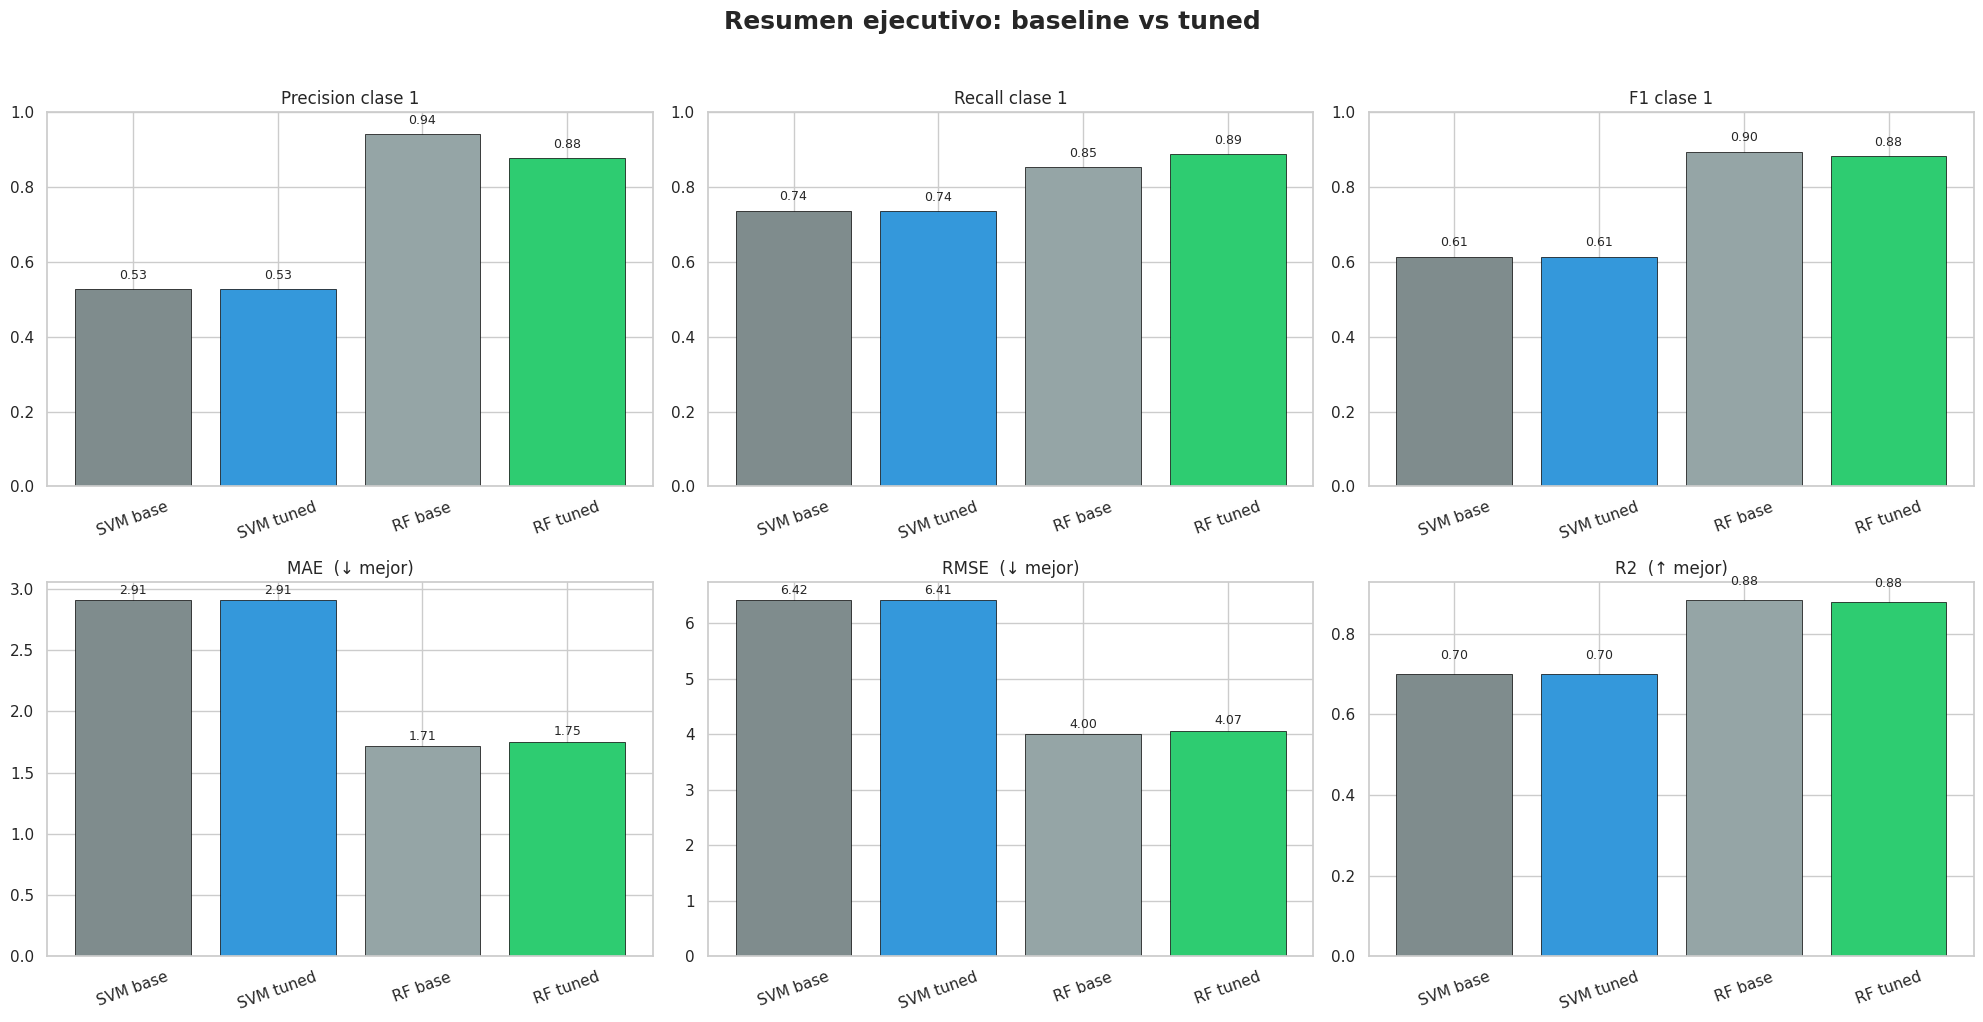

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# =========================================================
# 1. RESUMEN DE MÉTRICAS: BASE VS TUNED
# =========================================================

clf_perf = pd.DataFrame({
    "Modelo": ["SVM base", "SVM tuned", "RF base", "RF tuned"],
    "Precision clase 1": [
        precision_score(y_test_clf, y_pred_svm_clf),
        precision_score(y_test_clf, y_pred_svm_clf_tuned),
        precision_score(y_test_clf, y_pred_rf_clf),
        precision_score(y_test_clf, y_pred_rf_clf_tuned),
    ],
    "Recall clase 1": [
        recall_score(y_test_clf, y_pred_svm_clf),
        recall_score(y_test_clf, y_pred_svm_clf_tuned),
        recall_score(y_test_clf, y_pred_rf_clf),
        recall_score(y_test_clf, y_pred_rf_clf_tuned),
    ],
    "F1 clase 1": [
        f1_score(y_test_clf, y_pred_svm_clf),
        f1_score(y_test_clf, y_pred_svm_clf_tuned),
        f1_score(y_test_clf, y_pred_rf_clf),
        f1_score(y_test_clf, y_pred_rf_clf_tuned),
    ],
})

reg_perf = pd.DataFrame({
    "Modelo": ["SVM base", "SVM tuned", "RF base", "RF tuned"],
    "MAE": [
        mean_absolute_error(y_test_reg, y_pred_svm_reg),
        mae_svm_tuned,
        mean_absolute_error(y_test_reg, y_pred_rf_reg),
        mae_rf_tuned,
    ],
    "RMSE": [
        np.sqrt(mean_squared_error(y_test_reg, y_pred_svm_reg)),
        rmse_svm_tuned,
        np.sqrt(mean_squared_error(y_test_reg, y_pred_rf_reg)),
        rmse_rf_tuned,
    ],
    "R2": [
        r2_score(y_test_reg, y_pred_svm_reg),
        r2_svm_tuned,
        r2_score(y_test_reg, y_pred_rf_reg),
        r2_rf_tuned,
    ],
})

colors = ["#7f8c8d", "#3498db", "#95a5a6", "#2ecc71"]

fig, axes = plt.subplots(2, 3, figsize=(20, 10))
fig.suptitle("Resumen ejecutivo: baseline vs tuned", fontsize=18, fontweight="bold", y=1.02)

# --- clasificación ---
clf_metrics = ["Precision clase 1", "Recall clase 1", "F1 clase 1"]
for i, metric in enumerate(clf_metrics):
    ax = axes[0, i]
    vals = clf_perf[metric].values
    bars = ax.bar(clf_perf["Modelo"], vals, color=colors, edgecolor="black", linewidth=0.5)
    ax.set_title(metric)
    ax.set_ylim(0, 1)
    ax.tick_params(axis="x", rotation=20)
    for b, v in zip(bars, vals):
        ax.text(b.get_x() + b.get_width()/2, v + 0.02, f"{v:.2f}", ha="center", va="bottom", fontsize=9)

# --- regresión ---
reg_metrics = ["MAE", "RMSE", "R2"]
for i, metric in enumerate(reg_metrics):
    ax = axes[1, i]
    vals = reg_perf[metric].values
    bars = ax.bar(reg_perf["Modelo"], vals, color=colors, edgecolor="black", linewidth=0.5)
    ax.set_title(metric + ("  (↓ mejor)" if metric in ["MAE", "RMSE"] else "  (↑ mejor)"))
    ax.tick_params(axis="x", rotation=20)
    for b, v in zip(bars, vals):
        ax.text(b.get_x() + b.get_width()/2, v + (0.03 if metric == "R2" else max(vals)*0.01), f"{v:.2f}", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()

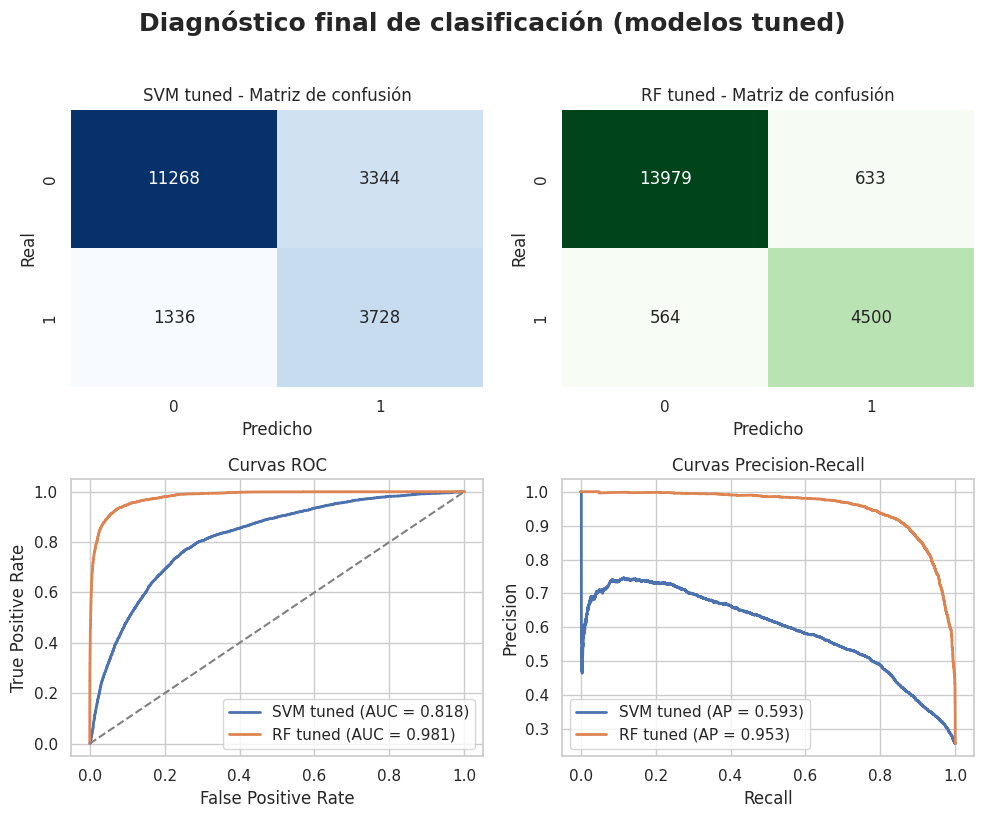

In [ ]:
from sklearn.metrics import confusion_matrix, roc_curve, auc, precision_recall_curve, average_precision_score

# Scores de los modelos tuned
score_svm_tuned = best_svm_clf.decision_function(X_test_clf)
score_rf_tuned = best_rf_clf.predict_proba(X_test_clf)[:, 1]

cm_svm_tuned = confusion_matrix(y_test_clf, y_pred_svm_clf_tuned)
cm_rf_tuned = confusion_matrix(y_test_clf, y_pred_rf_clf_tuned)

fpr_svm, tpr_svm, _ = roc_curve(y_test_clf, score_svm_tuned)
fpr_rf, tpr_rf, _ = roc_curve(y_test_clf, score_rf_tuned)

roc_auc_svm = auc(fpr_svm, tpr_svm)
roc_auc_rf = auc(fpr_rf, tpr_rf)

prec_svm, rec_svm, _ = precision_recall_curve(y_test_clf, score_svm_tuned)
prec_rf, rec_rf, _ = precision_recall_curve(y_test_clf, score_rf_tuned)

ap_svm = average_precision_score(y_test_clf, score_svm_tuned)
ap_rf = average_precision_score(y_test_clf, score_rf_tuned)

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
fig.suptitle("Diagnóstico final de clasificación (modelos tuned)", fontsize=18, fontweight="bold", y=1.02)

sns.heatmap(cm_svm_tuned, annot=True, fmt="d", cmap="Blues", cbar=False, ax=axes[0, 0])
axes[0, 0].set_title("SVM tuned - Matriz de confusión")
axes[0, 0].set_xlabel("Predicho")
axes[0, 0].set_ylabel("Real")

sns.heatmap(cm_rf_tuned, annot=True, fmt="d", cmap="Greens", cbar=False, ax=axes[0, 1])
axes[0, 1].set_title("RF tuned - Matriz de confusión")
axes[0, 1].set_xlabel("Predicho")
axes[0, 1].set_ylabel("Real")

axes[1, 0].plot(fpr_svm, tpr_svm, label=f"SVM tuned (AUC = {roc_auc_svm:.3f})", linewidth=2)
axes[1, 0].plot(fpr_rf, tpr_rf, label=f"RF tuned (AUC = {roc_auc_rf:.3f})", linewidth=2)
axes[1, 0].plot([0, 1], [0, 1], linestyle="--", color="gray")
axes[1, 0].set_title("Curvas ROC")
axes[1, 0].set_xlabel("False Positive Rate")
axes[1, 0].set_ylabel("True Positive Rate")
axes[1, 0].legend()

axes[1, 1].plot(rec_svm, prec_svm, label=f"SVM tuned (AP = {ap_svm:.3f})", linewidth=2)
axes[1, 1].plot(rec_rf, prec_rf, label=f"RF tuned (AP = {ap_rf:.3f})", linewidth=2)
axes[1, 1].set_title("Curvas Precision-Recall")
axes[1, 1].set_xlabel("Recall")
axes[1, 1].set_ylabel("Precision")
axes[1, 1].legend()

plt.tight_layout()
plt.show()

#**Conclusiones de la Optimización y Validación Avanzada**

La fase de optimización y validación avanzada permitió comprobar que los resultados obtenidos durante el entrenamiento inicial no fueron producto del azar ni de una partición específica de los datos. Mediante técnicas de validación cruzada, ajuste de hiperparámetros y análisis de importancia de variables, se verificó la robustez, estabilidad y capacidad de generalización de los modelos desarrollados.

Los resultados de validación cruzada mostraron un comportamiento altamente consistente para Random Forest, alcanzando un F1 promedio cercano a 0.86 y una Balanced Accuracy superior a 0.89. La baja variación observada entre los distintos folds confirma que el modelo mantiene un desempeño estable frente a diferentes muestras del dataset, reduciendo el riesgo de sobreajuste y aumentando la confianza en su capacidad predictiva sobre datos no observados previamente.

Por su parte, SVM presentó un desempeño considerablemente inferior, con valores de F1 cercanos a 0.61 incluso después de aplicar técnicas de balanceo y optimización. Aunque el ajuste de hiperparámetros permitió mejorar significativamente la detección de pit stops, el modelo continuó mostrando limitaciones para capturar la complejidad y naturaleza no lineal de las decisiones estratégicas presentes en una carrera de Fórmula 1.

Uno de los hallazgos más relevantes del proyecto fue comprobar que las mejoras obtenidas mediante Grid Search fueron relativamente pequeñas respecto al rendimiento inicial del Random Forest. Este comportamiento sugiere que la mayor parte de la capacidad predictiva del sistema no provino del ajuste fino de parámetros, sino de las etapas previas de preparación de datos, control de fuga de información y construcción de variables. En otras palabras, la calidad del modelado estuvo determinada principalmente por la calidad de las características diseñadas y no por la búsqueda de configuraciones complejas del algoritmo.

El análisis de importancia de variables aportó además evidencia consistente con la lógica estratégica observada en la Fórmula 1. Variables relacionadas con desgaste relativo del neumático, degradación acumulada, evolución reciente del ritmo y características del stint concentraron gran parte de la capacidad explicativa del modelo. Esto demuestra que el sistema logró aprender patrones coherentes con la dinámica real de carrera y no simplemente relaciones espurias presentes en los datos históricos.

En la tarea de clasificación, el modelo Random Forest alcanzó valores cercanos al 94%-95% de precisión global y un F1 próximo a 0.90 para la detección de futuros pit stops, mostrando una capacidad muy alta para identificar correctamente eventos estratégicos de parada. Desde una perspectiva operativa, esto significa que el modelo puede anticipar con elevada confiabilidad cuándo un piloto se encuentra próximo a ingresar a boxes, convirtiéndose en una herramienta potencialmente útil para apoyar procesos de simulación y análisis estratégico.

En la tarea de regresión, Random Forest logró explicar aproximadamente el 90% de la variabilidad observada en los tiempos de vuelta (R² ≈ 0.905), con un error medio absoluto cercano a 1.6 segundos por vuelta. Estos resultados indican que el modelo es capaz de capturar gran parte de los factores que afectan el rendimiento en pista, proporcionando estimaciones suficientemente precisas para aplicaciones de análisis deportivo y evaluación de estrategias.

De forma global, la validación avanzada confirma que Random Forest constituye la mejor alternativa entre los modelos evaluados tanto para clasificación como para regresión. Asimismo, los resultados evidencian que las etapas de análisis exploratorio, selección de variables, control de fuga de información y feature engineering tuvieron un impacto determinante en el desempeño final del sistema, validando la solidez metodológica seguida durante todo el proyecto.

Finalmente, puede concluirse que el conjunto de modelos desarrollados logra representar adecuadamente fenómenos clave de la estrategia de carrera en Fórmula 1, especialmente aquellos relacionados con degradación de neumáticos, gestión del stint y toma de decisiones de pit stop. Esto demuestra que los datos contienen señales predictivas reales y que es posible construir modelos con capacidad de generalización para apoyar procesos de análisis y simulación estratégica dentro del contexto competitivo del automovilismo.

# **>FIN**